In [89]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [90]:
from dataclasses import dataclass

from tqdm import tqdm

import orjson
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, TensorDataset, random_split
from tqdm import tqdm, trange

from sae_java_bug.logger import logger
from sae_java_bug.sparse_autoencoders.utils import get_device


@dataclass
class VulnerabilityData:
    vulnerable: torch.Tensor
    secure: torch.Tensor


In [93]:
import glob
import orjson
import torch
from tqdm import tqdm
from sae_java_bug.sparse_autoencoders.sae_exploration import ActivationsSchema

from sae_java_bug.logger import logger
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
from typing import Dict, Tuple
from sklearn.model_selection import KFold

class MLP(nn.Module):
    def __init__(
        self, input_dim, output_dim=2, hidden=(128, 64), dropout=0.3, use_bn=True
    ):
        super().__init__()
        h1, h2 = hidden
        self.use_bn = use_bn

        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1) if use_bn else nn.Identity()
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2) if use_bn else nn.Identity()
        self.fc3 = nn.Linear(h2, output_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc3(x)  # logits
        return x

def evaluate(loader, model, device=get_device(verbose=False)):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())
    y_true = torch.cat(all_labels)
    y_pred = torch.cat(all_preds)
    return accuracy_score(y_true, y_pred), y_true, y_pred

def train_small_mlp_kfold(class_negative: torch.Tensor, class_positive: torch.Tensor, k=5):

    # Create labels
    vuln_labels = torch.ones(class_positive.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(class_negative.size(0), dtype=torch.float32)

    all_features = torch.cat((class_positive, class_negative), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # print("All Features Shape:", all_features.shape)
    # print("All Labels Shape:", all_labels.shape)

    dataset = TensorDataset(all_features, all_labels)

    # Initialize KFold
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold = 1
    fold_acc = []

    for train_idx, test_idx in kf.split(all_features):

        # print(f"\n===== Fold {fold}/{k} =====")
        fold += 1

        train_subset = torch.utils.data.Subset(dataset, train_idx)
        test_subset  = torch.utils.data.Subset(dataset, test_idx)

        train_loader = DataLoader(train_subset, batch_size=32, shuffle=True, drop_last=True)
        test_loader  = DataLoader(test_subset, batch_size=1000, shuffle=False, drop_last=False)

        # new model per fold
        model = MLP(input_dim=all_features.size(1)).to(device)
        # activate gradients
        model.train()
        torch.set_grad_enabled(True)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

        num_epochs = 50  # often fewer needed

        for epoch in range(num_epochs):
            model.train()
            for x_batch, y_batch in train_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)

                optimizer.zero_grad()
                logits = model(x_batch)
                loss = F.cross_entropy(logits, y_batch)
                loss.backward()
                optimizer.step()

        # evaluate this fold
        acc, _, _ = evaluate(test_loader, model, device)
        fold_acc.append(acc)

    #     print(f"Fold Test Accuracy: {acc:.4f}")

    # print("\n===== K-Fold Results =====")
    # print(f"Fold Accuracies: {fold_acc}")
    # print(f"Mean Accuracy: {sum(fold_acc)/len(fold_acc):.4f}")

    return sum(fold_acc)/len(fold_acc)


device = get_device(verbose=True)

layer_scores = {}
RUN_ID = "run_20260127_044329"
RUN_ID = "run_20260127_195450" # this is the swapped operands activations
RUN_ID = "run_20260127_202722" # this is the cwes data
RUN_ID = "run_20260128_184854" # Trained with DeltaSeccommits
RUN_ID = "run_20260131_190935_rufimelo_secure_code_qwen_coder_strd_16384"
RUN_ID = "run_20260202_220441_rufimelo_secure_code_qwen_coder_topk_16384"


files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"), key=lambda x: int(x.split("layer_")[1].split("_")[0]))

@dataclass
class VulnerabilityData:
    vulnerable: torch.Tensor
    secure: torch.Tensor


def compute_lda_fisher_scores(secure_features: torch.Tensor, vulnerable_features: torch.Tensor) -> float:
    # Create labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA — build dataset for layer
    X = all_features.numpy()
    y = all_labels.numpy()

    # Train LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(X, y)

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    mean_diff = vuln_proj.mean() - safe_proj.mean()
    var_sum = vuln_proj.var() + safe_proj.var()
    fisher_score = (mean_diff ** 2) / (var_sum + 1e-8)

    return float(fisher_score)


2026-02-02 22:15:37 [info     ] Getting device.                device=mps


In [94]:


FisherScoreMap: Dict[Tuple[str, str], float] = {}
ProbingDataMap: Dict[Tuple[str, str], float] = {}
from typing import List
from collections import defaultdict

all_vulnerable_features: Dict[str, List[float]] = defaultdict(list)
all_safe_features : Dict[str, List[float]] = defaultdict(list)

for activation_file in files:
    logger.info("Processing file.", file=activation_file)

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    
    # Loads activations.
    with open(activation_file, "r") as f: 
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            try:
                data = orjson.loads(line)
            except orjson.JSONDecodeError as e:
                logger.error(f"JSON decoding error: {e}")
                # skip to the next file
                break
            
            cwe = data["cwe"]
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)


            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)
            

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )

        print("Vulnerable Features Shape:", vulnerable_features.shape , "Safe Features Shape:", safe_features.shape)
        print("CWE:", cwe, "Vulnerable Shape:", vulnerable_features.shape, "Safe Shape:", safe_features.shape)
    
        all_vulnerable_features[
            "layer_" + activation_file.split("layer_")[1].split("_")[0]
        ] = torch.tensor(vulnerable_features)
        all_safe_features[
            "layer_" + activation_file.split("layer_")[1].split("_")[0]
        ]= torch.tensor(safe_features)
        

    # Save for later reuse
    layer_id = activation_file.split("layer_")[1].split("_")[0]
    torch.save(vulnerable_features, f"../artifacts/activations/{RUN_ID}/vulnerable_layer_{layer_id}.pt")
    torch.save(safe_features, f"../artifacts/activations/{RUN_ID}/safe_layer_{layer_id}.pt")

2026-02-02 22:15:40 [info     ] Processing file.               file=../artifacts/activations/run_20260202_220441_rufimelo_secure_code_qwen_coder_topk_16384/activations_layer_0_sae_blocks.0.hook_resid_post_component_hook_resid_post.hook_sae_acts_post.jsonl


Loading: 100%|█████████▉| 2493/2500 [03:14<00:00, 12.79 lines/s]
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_4416/3811333901.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ] = torch.tensor(vulnerable_features)
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_4416/3811333901.py:61: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ]= torch.tensor(safe_features)


Vulnerable Features Shape: torch.Size([2493, 16384]) Safe Features Shape: torch.Size([2493, 16384])
CWE: CWE-787 Vulnerable Shape: torch.Size([2493, 16384]) Safe Shape: torch.Size([2493, 16384])


In [95]:
# for key, data in tqdm(cwe_tensor_map.items()):
#     try:
#         # fisher_score = compute_lda_fisher_scores(data.secure, data.vulnerable)
#         # FisherScoreMap[(layer_id, key)] = fisher_score
#         probe_score = train_small_mlp_kfold(data.secure, data.vulnerable, k=5)
#         ProbingDataMap[(layer_id, key)] = probe_score
#     except Exception as e:
#         logger.error(f"Error processing CWE {key} in layer {layer_id}: {e}")


# # fisher_score = compute_lda_fisher_scores(safe_features, vulnerable_features)
# # FisherScoreMap[(layer_id, "ALL")] = fisher_score
# probe_score = train_small_mlp_kfold(safe_features, vulnerable_features, k=5)
# ProbingDataMap[(layer_id, "ALL")] = probe_score

In [96]:
files = sorted(glob.glob(f"../artifacts/activations/{RUN_ID}/activations_layer_*"))

def get_data(files: list, layer_id: int, cwe: str):
    # Read file and extract data for given layer_id and cwe
    for file in files:
        if f"layer_{layer_id}_" in file:
            activation_file = file
            break
    else:
        raise ValueError(f"Layer {layer_id} not found in files.")
    

    cwe_tensor_map: Dict[str, VulnerabilityData] = {}
    vulnerable_features = torch.tensor([])
    safe_features = torch.tensor([])
    # Loads activations.
    with open(activation_file, "r") as f:
        for line in tqdm(f, desc="Loading", unit=" lines", total=2500):
            try:
                data = orjson.loads(line)
            except orjson.JSONDecodeError as e:
                logger.error(f"JSON decoding error: {e}")
                # skip to the next file
                break
            _cwe = data["cwe"]
            if _cwe != cwe:
                continue
            if cwe not in cwe_tensor_map:
                cwe_tensor_map[cwe] = VulnerabilityData(
                    vulnerable=torch.tensor([]),
                    secure=torch.tensor([]),
                )

            activations = ActivationsSchema(**data)
            # print(f"Vuln ID: {activations.vuln_id}, Layer: {activations.layer}")
            vuln_tensor = torch.tensor(activations.vulnerable)
            safe_tensor = torch.tensor(activations.secure)



            vulnerable_features = torch.cat(
                (vulnerable_features, vuln_tensor.unsqueeze(0)), dim=0
            )
            safe_features = torch.cat((safe_features, safe_tensor.unsqueeze(0)), dim=0)

            cwe_tensor_map[cwe] = VulnerabilityData(
                vulnerable=torch.cat(
                    (cwe_tensor_map[cwe].vulnerable, vuln_tensor.unsqueeze(0)), dim=0
                ),
                secure=torch.cat(
                    (cwe_tensor_map[cwe].secure, safe_tensor.unsqueeze(0)), dim=0
                ),
            )


    return cwe_tensor_map[cwe]


def plot_pca(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # PCA
    pca = PCA(n_components=2)
    proj = pca.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label=label_vulnerable, alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label=label_secure, alpha=0.5)
    plt.title("PCA of Activations")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend()
    plt.grid()
    plt.show()


def plot_lda(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # LDA
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(all_features.numpy(), all_labels.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.hist(vuln_proj, bins=30, alpha=0.5, label=label_vulnerable, color="r")
    plt.hist(safe_proj, bins=30, alpha=0.5, label=label_secure, color="g")
    plt.title("LDA of Activations")
    plt.xlabel("LDA Component 1")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()


def plot_tsne(secure_features: torch.Tensor, vulnerable_features: torch.Tensor, label_secure="Secure", label_vulnerable="Vulnerable"):
    from sklearn.manifold import TSNE
    import matplotlib.pyplot as plt

    # Combine features and labels
    vuln_labels = torch.ones(vulnerable_features.size(0), dtype=torch.float32)
    safe_labels = torch.zeros(secure_features.size(0), dtype=torch.float32)
    all_features = torch.cat((vulnerable_features, secure_features), dim=0).float()
    all_labels = torch.cat((vuln_labels, safe_labels), dim=0).long()

    # t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    proj = tsne.fit_transform(all_features.numpy())

    vuln_proj = proj[: len(vulnerable_features)]
    safe_proj = proj[len(vulnerable_features):]

    plt.figure(figsize=(8, 6))
    plt.scatter(
        vuln_proj[:, 0], vuln_proj[:, 1], c="r", label=label_vulnerable, alpha=0.5
    )
    plt.scatter(safe_proj[:, 0], safe_proj[:, 1], c="g", label=label_secure, alpha=0.5)
    plt.title("t-SNE of Activations")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend()
    plt.grid()
    plt.show()

In [97]:


# for key in FisherScoreMap:
#     if key == "ALL":
#         continue
#     logger.info(f"Layer {key[0]}, CWE {key[1]}: LDA Fisher Score = {FisherScoreMap[key]:.4f}, Probing Accuracy = {ProbingDataMap[key]:.4f}")
#     layer_id = int(key[0])
#     cwe = key[1]
#     data = get_data(files, layer_id, cwe)
#     plot_pca(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")
#     plot_tsne(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")
#     plot_lda(data.secure, data.vulnerable, label_secure="Secure", label_vulnerable="Vulnerable")
# plot_pca(all_safe_features["layer_0"], all_vulnerable_features["layer_0"], label_secure="Secure", label_vulnerable="Vulnerable")

# plot_tsne(all_safe_features["layer_0"], all_vulnerable_features["layer_0"], label_secure="Secure", label_vulnerable="Vulnerable")


# Paper Plan

## Per-sample mean latent activation

In [98]:
from dataclasses import dataclass
from typing import Optional, Tuple
from enum import Enum
import pickle
from tqdm import tqdm
import numpy as np
import torch
import matplotlib.pyplot as plt


class FeatureType(Enum):
    """Classification based on activation frequency p_i = P(z_i > ε)."""
    ACTIVE = "active"      # p_i >= 10%: fires often, model with range
    DORMANT = "dormant"    # p_i < 10%: rarely fires, flag any activation


@dataclass
class FeatureInvariant:
    """Invariant for a single SAE feature."""
    feature_idx: int
    feature_type: FeatureType
    activation_freq: float  # p_i = P(z_i > ε) on secure data
    
    # For ACTIVE features: range statistics
    median: Optional[float] = None
    mad: Optional[float] = None
    q1: Optional[float] = None
    q3: Optional[float] = None
    iqr: Optional[float] = None
    
    # For DORMANT features: activation threshold
    activation_threshold: float = 0.0  # θ_i: 99.9th percentile of secure activations
    
    def is_range_violation(self, value: float, k: float = 3.0) -> bool:
        """
        Check if value violates the range invariant (ACTIVE features only).
        Returns False for DORMANT features.
        """
        if self.feature_type != FeatureType.ACTIVE:
            return False
        if self.mad is None or self.mad == 0:
            return False
        lower = self.median - k * self.mad
        upper = self.median + k * self.mad
        return value < lower or value > upper
    
    def is_activation_violation(self, value: float) -> bool:
        """
        Check if value violates the dormancy invariant (DORMANT features only).
        Returns True if a dormant feature fires above its threshold.
        """
        if self.feature_type != FeatureType.DORMANT:
            return False
        return value > self.activation_threshold
    
    def range_violation_score(self, value: float) -> float:
        """
        Compute |z - median| / MAD for ACTIVE features.
        Returns 0 for DORMANT features.
        """
        if self.feature_type != FeatureType.ACTIVE:
            return 0.0
        if self.mad is None or self.mad == 0:
            return 0.0
        return abs(value - self.median) / self.mad


def compute_mad(values: np.ndarray) -> float:
    """Compute Median Absolute Deviation."""
    median = np.median(values)
    return np.median(np.abs(values - median))


def compute_feature_invariants(
    secure_activations: torch.Tensor,
    activation_freq_threshold: float = 0.10,  # 10% threshold
    noise_epsilon: float = 1e-6,
    dormant_percentile: float = 99.9,
) -> list[FeatureInvariant]:
    """
    Compute feature invariants based on secure code activations.
    
    Step A: Classify by activation frequency p_i = P(z_i > ε)
    Step B: Compute appropriate statistics for each type
    
    Args:
        secure_activations: Tensor of shape (n_samples, n_features)
        activation_freq_threshold: Features with p_i >= this are ACTIVE
        noise_epsilon: Threshold for "active" (non-zero) activation
        dormant_percentile: Percentile for dormant activation threshold
    """
    secure_np = secure_activations.numpy()
    n_samples, n_features = secure_np.shape
    
    invariants = []
    
    print(f"Computing feature invariants for {n_features} features...")
    print(f"  Activation frequency threshold: {activation_freq_threshold*100:.0f}%")
    print(f"  Noise epsilon: {noise_epsilon}")
    print(f"  Dormant threshold percentile: {dormant_percentile}")
    
    for i in tqdm(range(n_features), desc="Processing features"):
        feature_values = secure_np[:, i]
        
        # Step A: Compute activation frequency p_i = P(z_i > ε)
        activation_freq = (feature_values > noise_epsilon).sum() / n_samples
        
        # Classify feature
        if activation_freq >= activation_freq_threshold:
            feature_type = FeatureType.ACTIVE
        else:
            feature_type = FeatureType.DORMANT
        
        # Step B: Compute type-specific statistics
        if feature_type == FeatureType.ACTIVE:
            # Active features: compute range statistics on all values
            median = np.median(feature_values)
            mad = compute_mad(feature_values)
            q1 = np.percentile(feature_values, 25)
            q3 = np.percentile(feature_values, 75)
            iqr = q3 - q1
            activation_threshold = 0.0  # Not used for active features
            
            invariants.append(FeatureInvariant(
                feature_idx=i,
                feature_type=feature_type,
                activation_freq=activation_freq,
                median=median,
                mad=mad,
                q1=q1,
                q3=q3,
                iqr=iqr,
                activation_threshold=activation_threshold,
            ))
        else:
            # Dormant features: compute activation threshold θ_i
            # Use high percentile (99.9%) of all values as threshold
            activation_threshold = np.percentile(feature_values, dormant_percentile)
            
            invariants.append(FeatureInvariant(
                feature_idx=i,
                feature_type=feature_type,
                activation_freq=activation_freq,
                activation_threshold=activation_threshold,
            ))
    
    return invariants


@dataclass
class SampleViolationScores:
    """Violation scores for a single sample."""
    # Active feature violations
    range_violation_score: float  # Sum of |z - median| / MAD for active features
    range_violation_count: int    # Number of active features outside k*MAD
    n_active_features: int
    
    # Dormant feature violations
    activation_violation_count: int  # Number of dormant features that fired
    n_dormant_features: int
    
    # Per-feature details (for analysis)
    active_violations: list[int] = None    # Indices of violated active features
    dormant_violations: list[int] = None   # Indices of violated dormant features


def compute_sample_violations(
    sample: np.ndarray,
    invariants: list[FeatureInvariant],
    k: float = 3.0,
) -> SampleViolationScores:
    """
    Compute violation scores for a single sample.
    
    Args:
        sample: 1D array of activations
        invariants: List of FeatureInvariant objects
        k: MAD multiplier for range violations
    """
    range_violation_score = 0.0
    range_violation_count = 0
    activation_violation_count = 0
    
    n_active = 0
    n_dormant = 0
    
    active_violations = []
    dormant_violations = []
    
    for inv in invariants:
        value = sample[inv.feature_idx]
        
        if inv.feature_type == FeatureType.ACTIVE:
            n_active += 1
            # Compute range violation score
            score = inv.range_violation_score(value)
            range_violation_score += score
            
            # Check if it's a violation (outside k*MAD)
            if inv.is_range_violation(value, k):
                range_violation_count += 1
                active_violations.append(inv.feature_idx)
        
        else:  # DORMANT
            n_dormant += 1
            # Check if dormant feature activated
            if inv.is_activation_violation(value):
                activation_violation_count += 1
                dormant_violations.append(inv.feature_idx)
    
    return SampleViolationScores(
        range_violation_score=range_violation_score,
        range_violation_count=range_violation_count,
        n_active_features=n_active,
        activation_violation_count=activation_violation_count,
        n_dormant_features=n_dormant,
        active_violations=active_violations,
        dormant_violations=dormant_violations,
    )


def analyze_population(
    activations: torch.Tensor,
    invariants: list[FeatureInvariant],
    k: float = 3.0,
    label: str = "Population",
) -> list[SampleViolationScores]:
    """Compute violation scores for all samples in a population."""
    act_np = activations.numpy()
    scores = []
    
    for sample in tqdm(act_np, desc=f"Analyzing {label}"):
        scores.append(compute_sample_violations(sample, invariants, k))
    
    return scores



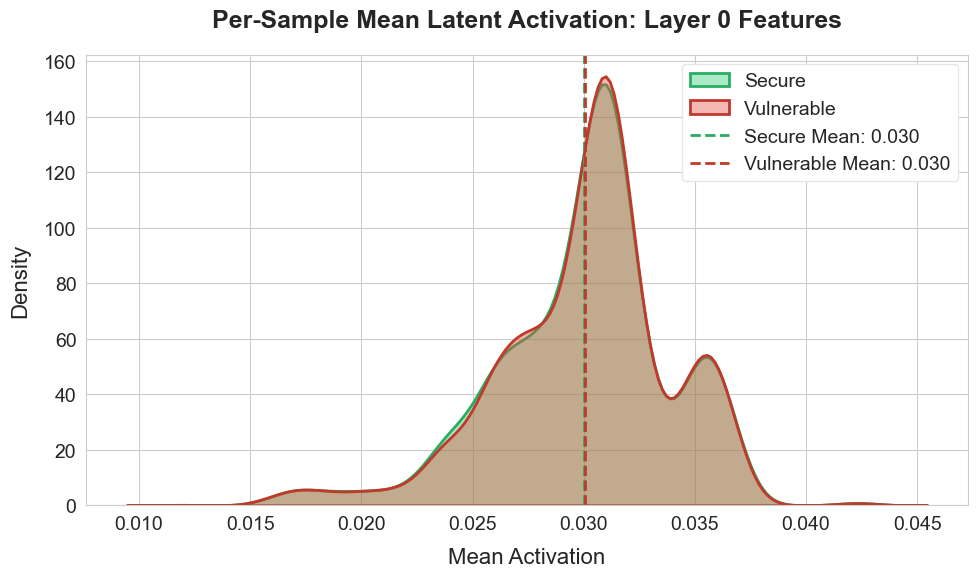

In [99]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from matplotlib import rcParams

# Set global styles for NeurIPS-quality plots
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.9",
    "grid.linestyle": "--",
    "lines.linewidth": 2,
})

def plot_mean_activations_kde(
    secure_activations: torch.Tensor,
    vulnerable_activations: torch.Tensor,
    layer_name: str = "Layer 0",
):
    secure_means = secure_activations.mean(dim=1).numpy()
    vulnerable_means = vulnerable_activations.mean(dim=1).numpy()

    # Calculate statistics for annotations
    secure_mean = np.mean(secure_means)
    vulnerable_mean = np.mean(vulnerable_means)
    secure_std = np.std(secure_means)
    vulnerable_std = np.std(vulnerable_means)

    # Create figure
    plt.figure(figsize=(10, 6), dpi=100)
    sns.set_style("whitegrid")

    # Plot KDEs with refined styling
    ax = sns.kdeplot(
        secure_means,
        label="Secure",
        fill=True,
        alpha=0.4,
        color="#2ecc71",  # Vibrant green
        linewidth=2,
        edgecolor="#27ae60",  # Darker green for edge
    )
    sns.kdeplot(
        vulnerable_means,
        label="Vulnerable",
        fill=True,
        alpha=0.4,
        color="#e74c3c",  # Vibrant red
        linewidth=2,
        edgecolor="#c0392b",  # Darker red for edge
    )

    # Add vertical lines for means with improved styling
    plt.axvline(
        secure_mean,
        color="#27ae60",
        linestyle="--",
        linewidth=2,
        label=f"Secure Mean: {secure_mean:.3f}",
    )
    plt.axvline(
        vulnerable_mean,
        color="#c0392b",
        linestyle="--",
        linewidth=2,
        label=f"Vulnerable Mean: {vulnerable_mean:.3f}",
    )

    # Add annotations for standard deviations
    plt.text(
        secure_mean + 0.01,
        0.9 * ax.get_ylim()[1],
        f"σ = {secure_std:.3f}",
        color="#27ae60",
        ha="left",
        va="top",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    )
    plt.text(
        vulnerable_mean + 0.01,
        0.8 * ax.get_ylim()[1],
        f"σ = {vulnerable_std:.3f}",
        color="#c0392b",
        ha="left",
        va="top",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
    )

    # Labels and title
    plt.title(
        f"Per-Sample Mean Latent Activation: {layer_name}",
        pad=20,
        fontsize=18,
        weight="bold",
    )
    plt.xlabel("Mean Activation", labelpad=10)
    plt.ylabel("Density", labelpad=10)

    # Legend with refined positioning
    plt.legend(
        loc="upper right",
        frameon=True,
        framealpha=1,
        facecolor="white",
        edgecolor="0.9",
        fancybox=True,
    )

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(f"mean_activations_{layer_name.replace(' ', '_')}.pdf", bbox_inches="tight", format="pdf")
    plt.show()

# Example usage
secure_activations = all_safe_features["layer_0"]
vulnerable_activations = all_vulnerable_features["layer_0"]
plot_mean_activations_kde(secure_activations, vulnerable_activations, layer_name="Layer 0 Features")


## L2 norm of latent vectors for both classes.

<>:85: SyntaxWarning: invalid escape sequence '\e'
<>:87: SyntaxWarning: invalid escape sequence '\e'
<>:85: SyntaxWarning: invalid escape sequence '\e'
<>:87: SyntaxWarning: invalid escape sequence '\e'
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_4416/1693798106.py:85: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Per-Sample $\ell_2$ Norm', fontsize=14, labelpad=10)
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_4416/1693798106.py:87: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('Per-Sample Latent $\ell_2$ Norm', fontsize=16, fontweight='bold', pad=10)


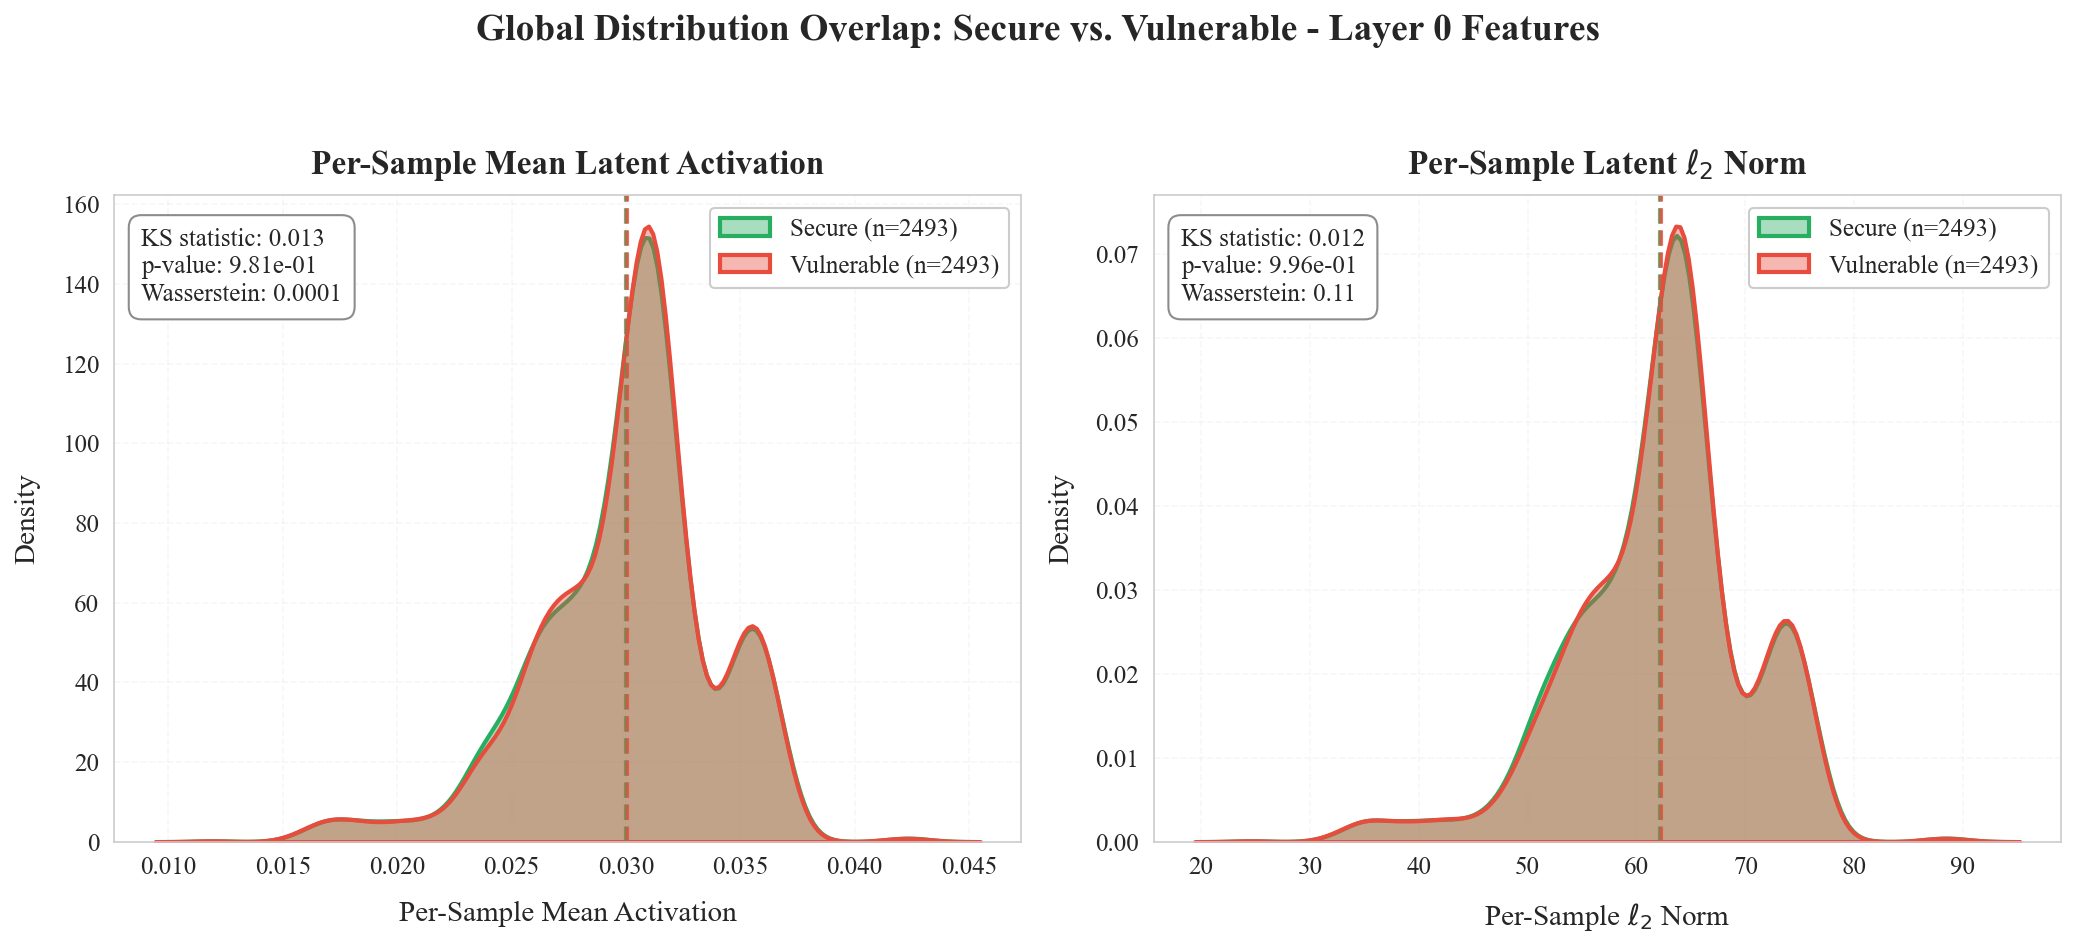


CLAIM: Vulnerable code does not form a globally anomalous population

Per-Sample Mean Activation:
  Secure:     μ = 0.030023 ± 0.003937
  Vulnerable: μ = 0.030059 ± 0.003915
  Overlap:    KS = 0.013, p = 9.81e-01
             Wasserstein distance = 0.0001

Per-Sample L2 Norm:
  Secure:     μ = 62.17 ± 8.16
  Vulnerable: μ = 62.24 ± 8.11
  Overlap:    KS = 0.012, p = 9.96e-01
             Wasserstein distance = 0.11

→ Conclusion: Distributions overlap heavily, explaining why PCA fails.


In [100]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance
from matplotlib import rcParams

# Set global styles for NeurIPS-quality plots
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.9",
    "grid.linestyle": "--",
    "lines.linewidth": 2,
})

def plot_global_distribution_overlap(secure_activations, vulnerable_activations, layer_name="Layer 0"):
    # Convert to numpy
    secure_np = secure_activations.numpy()
    vuln_np = vulnerable_activations.numpy()

    # Compute per-sample statistics
    secure_mean_activation = np.mean(secure_np, axis=1)
    vuln_mean_activation = np.mean(vuln_np, axis=1)
    secure_l2_norm = np.linalg.norm(secure_np, axis=1)
    vuln_l2_norm = np.linalg.norm(vuln_np, axis=1)

    # Create figure with improved layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
    fig.suptitle(f'Global Distribution Overlap: Secure vs. Vulnerable - {layer_name}',
                fontsize=18, fontweight='bold', y=1.05)

    # Panel 1: Per-Sample Mean Latent Activation
    ax = axes[0]
    sns.kdeplot(secure_mean_activation, ax=ax, color='#27AE60', fill=True, alpha=0.4,
                label=f'Secure (n={len(secure_mean_activation)})', linewidth=2)
    sns.kdeplot(vuln_mean_activation, ax=ax, color='#E74C3C', fill=True, alpha=0.4,
                label=f'Vulnerable (n={len(vuln_mean_activation)})', linewidth=2)

    # Add vertical lines for means
    ax.axvline(np.mean(secure_mean_activation), color='#27AE60', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(np.mean(vuln_mean_activation), color='#E74C3C', linestyle='--', linewidth=2, alpha=0.8)

    # Compute overlap statistics
    ks_stat, ks_pval = ks_2samp(secure_mean_activation, vuln_mean_activation)
    ws_dist = wasserstein_distance(secure_mean_activation, vuln_mean_activation)

    ax.set_xlabel('Per-Sample Mean Activation', fontsize=14, labelpad=10)
    ax.set_ylabel('Density', fontsize=14, labelpad=10)
    ax.set_title('Per-Sample Mean Latent Activation', fontsize=16, fontweight='bold', pad=10)
    ax.legend(loc='upper right', fontsize=12, frameon=True, framealpha=1, facecolor='white')
    ax.grid(True, alpha=0.3)

    # Stats annotation with improved formatting
    stats_text = (f'KS statistic: {ks_stat:.3f}\n'
                 f'p-value: {ks_pval:.2e}\n'
                 f'Wasserstein: {ws_dist:.4f}')
    ax.text(0.03, 0.95, stats_text,
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Panel 2: Per-Sample L2 Norm
    ax = axes[1]
    sns.kdeplot(secure_l2_norm, ax=ax, color='#27AE60', fill=True, alpha=0.4,
                label=f'Secure (n={len(secure_l2_norm)})', linewidth=2)
    sns.kdeplot(vuln_l2_norm, ax=ax, color='#E74C3C', fill=True, alpha=0.4,
                label=f'Vulnerable (n={len(vuln_l2_norm)})', linewidth=2)

    # Add vertical lines for means
    ax.axvline(np.mean(secure_l2_norm), color='#27AE60', linestyle='--', linewidth=2, alpha=0.8)
    ax.axvline(np.mean(vuln_l2_norm), color='#E74C3C', linestyle='--', linewidth=2, alpha=0.8)

    # Compute overlap statistics
    ks_stat_l2, ks_pval_l2 = ks_2samp(secure_l2_norm, vuln_l2_norm)
    ws_dist_l2 = wasserstein_distance(secure_l2_norm, vuln_l2_norm)

    ax.set_xlabel('Per-Sample $\ell_2$ Norm', fontsize=14, labelpad=10)
    ax.set_ylabel('Density', fontsize=14, labelpad=10)
    ax.set_title('Per-Sample Latent $\ell_2$ Norm', fontsize=16, fontweight='bold', pad=10)
    ax.legend(loc='upper right', fontsize=12, frameon=True, framealpha=1, facecolor='white')
    ax.grid(True, alpha=0.3)

    # Stats annotation
    stats_text = (f'KS statistic: {ks_stat_l2:.3f}\n'
                 f'p-value: {ks_pval_l2:.2e}\n'
                 f'Wasserstein: {ws_dist_l2:.2f}')
    ax.text(0.03, 0.95, stats_text,
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Adjust layout
    plt.tight_layout()

    # # Add interpretation text below with improved styling
    # interpretation = ('⚠ Key Insight: Vulnerable code does NOT form a globally anomalous population.\n'
    #                  'The distributions overlap significantly → PCA/global outlier detection will fail.')
    # fig.text(0.5, 0.01, interpretation,
    #          ha='center', fontsize=14, style='italic',
    #          bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF9E6', alpha=0.9, edgecolor='#E0E0E0'))

    # Save and show

    plt.savefig(f"global_distribution_overlap_{layer_name.replace(' ', '_')}.pdf", bbox_inches="tight", format="pdf")
    plt.show()

    # Print summary with improved formatting
    print(f"\n{'='*80}")
    print("CLAIM: Vulnerable code does not form a globally anomalous population")
    print(f"{'='*80}")
    print(f"\nPer-Sample Mean Activation:")
    print(f"  Secure:     μ = {np.mean(secure_mean_activation):.6f} ± {np.std(secure_mean_activation):.6f}")
    print(f"  Vulnerable: μ = {np.mean(vuln_mean_activation):.6f} ± {np.std(vuln_mean_activation):.6f}")
    print(f"  Overlap:    KS = {ks_stat:.3f}, p = {ks_pval:.2e}")
    print(f"             Wasserstein distance = {ws_dist:.4f}")

    print(f"\nPer-Sample L2 Norm:")
    print(f"  Secure:     μ = {np.mean(secure_l2_norm):.2f} ± {np.std(secure_l2_norm):.2f}")
    print(f"  Vulnerable: μ = {np.mean(vuln_l2_norm):.2f} ± {np.std(vuln_l2_norm):.2f}")
    print(f"  Overlap:    KS = {ks_stat_l2:.3f}, p = {ks_pval_l2:.2e}")
    print(f"             Wasserstein distance = {ws_dist_l2:.2f}")

    print(f"\n→ Conclusion: Distributions overlap heavily, explaining why PCA fails.")
    print(f"{'='*80}")

# Example usage
plot_global_distribution_overlap(secure_activations, vulnerable_activations, layer_name="Layer 0 Features")


<>:94: SyntaxWarning: invalid escape sequence '\e'
<>:96: SyntaxWarning: invalid escape sequence '\e'
<>:94: SyntaxWarning: invalid escape sequence '\e'
<>:96: SyntaxWarning: invalid escape sequence '\e'
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_4416/2058623306.py:94: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('Per-Sample $\ell_2$ Norm', fontsize=14, labelpad=10)
/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_4416/2058623306.py:96: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('CDF: Per-Sample Latent $\ell_2$ Norm', fontsize=16, fontweight='bold', pad=10)


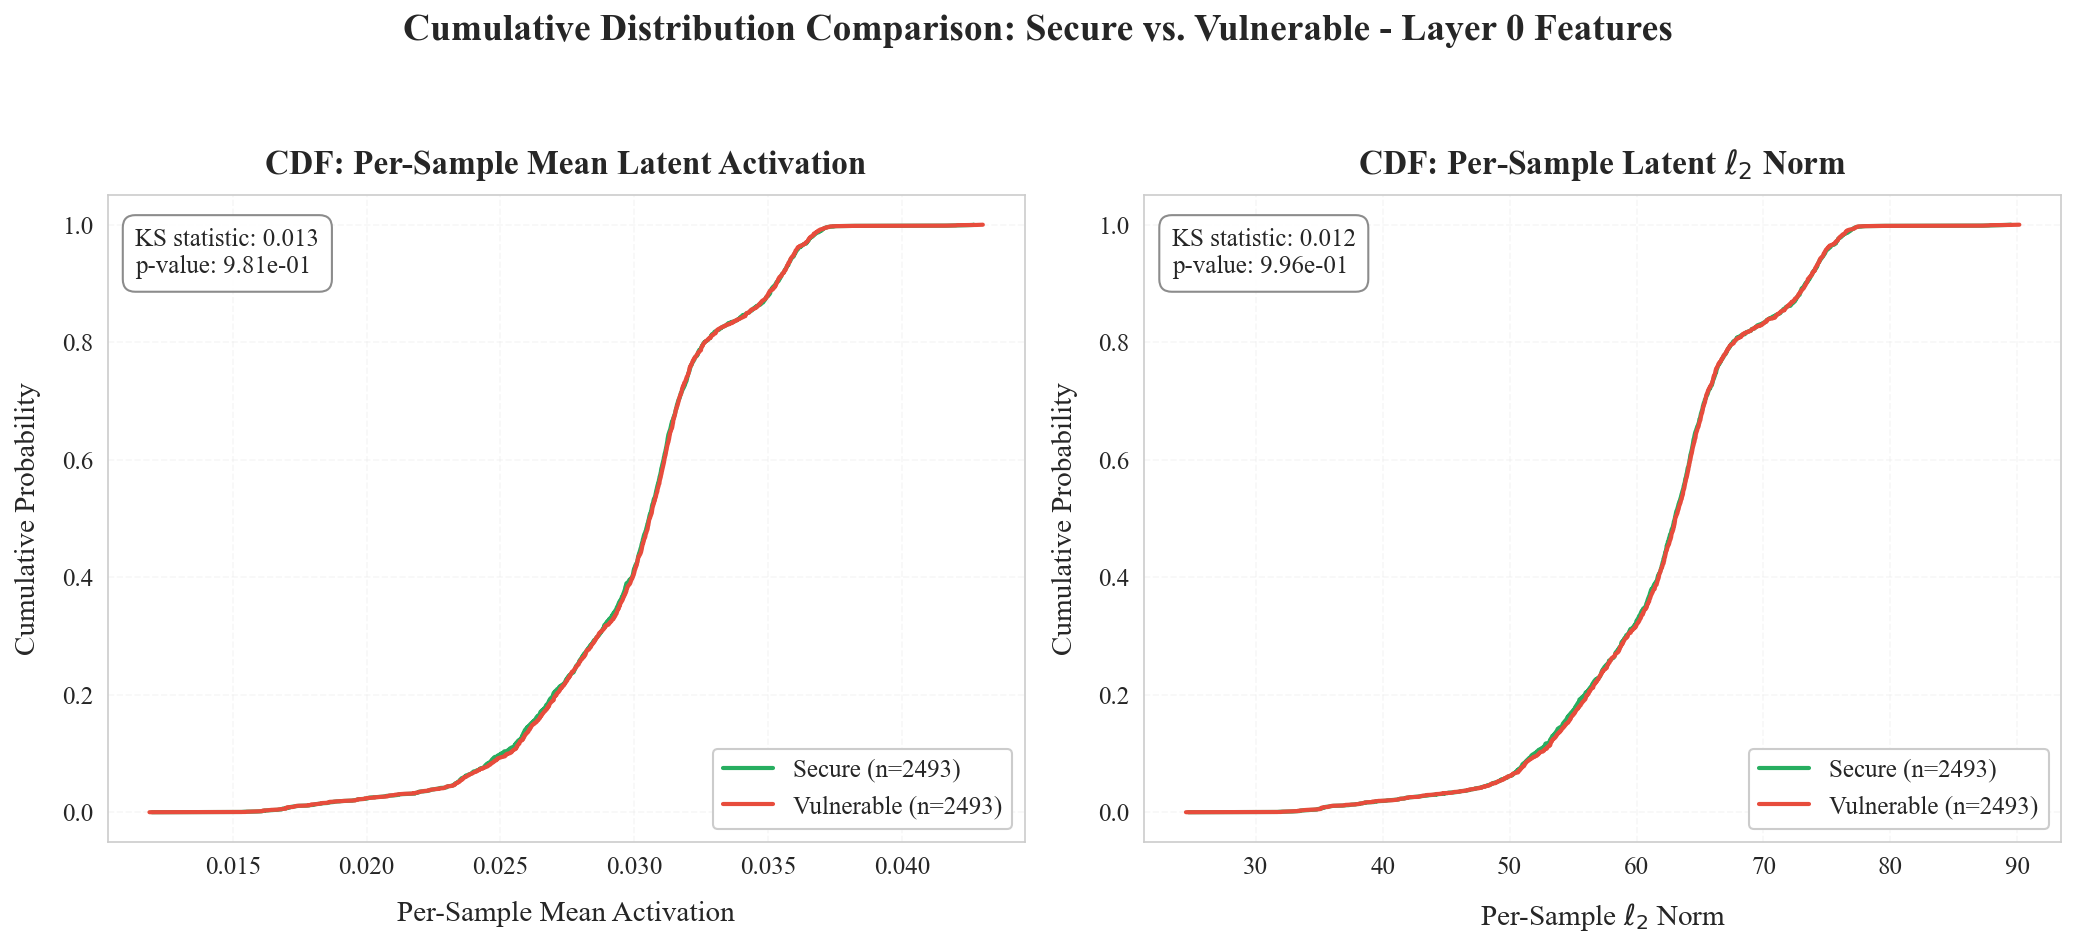


CLAIM: Vulnerable code cumulative distributions overlap heavily with secure code

Per-Sample Mean Activation KS Test:
  KS statistic: 0.013
  p-value: 9.81e-01

Per-Sample L2 Norm KS Test:
  KS statistic: 0.012
  p-value: 9.96e-01

→ Conclusion: CDFs are nearly identical, confirming no global separation.


In [101]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance
from matplotlib import rcParams

# Set global styles for NeurIPS-quality plots
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.color": "0.9",
    "grid.linestyle": "--",
    "lines.linewidth": 2,
})

def plot_cumulative_distribution(
    secure_activations: torch.Tensor,
    vulnerable_activations: torch.Tensor,
    layer_name: str = "Layer 0 Features"
):
    # Convert to numpy
    secure_np = secure_activations.numpy()
    vuln_np = vulnerable_activations.numpy()

    # Compute per-sample statistics
    secure_mean_activation = np.mean(secure_np, axis=1)
    vuln_mean_activation = np.mean(vuln_np, axis=1)
    secure_l2_norm = np.linalg.norm(secure_np, axis=1)
    vuln_l2_norm = np.linalg.norm(vuln_np, axis=1)

    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)
    fig.suptitle(f'Cumulative Distribution Comparison: Secure vs. Vulnerable - {layer_name}',
                fontsize=18, fontweight='bold', y=1.05)

    # Panel 1: CDF of Mean Activations
    ax = axes[0]

    # Sort the data for CDF
    sorted_secure = np.sort(secure_mean_activation)
    sorted_vuln = np.sort(vuln_mean_activation)

    # Calculate CDF values
    cdf_secure = np.arange(1, len(sorted_secure) + 1) / len(sorted_secure)
    cdf_vuln = np.arange(1, len(sorted_vuln) + 1) / len(sorted_vuln)

    # Plot CDFs
    ax.plot(sorted_secure, cdf_secure, color='#27AE60', linewidth=2, label=f'Secure (n={len(sorted_secure)})')
    ax.plot(sorted_vuln, cdf_vuln, color='#E74C3C', linewidth=2, label=f'Vulnerable (n={len(sorted_vuln)})')

    # Compute overlap statistics
    ks_stat, ks_pval = ks_2samp(secure_mean_activation, vuln_mean_activation)

    ax.set_xlabel('Per-Sample Mean Activation', fontsize=14, labelpad=10)
    ax.set_ylabel('Cumulative Probability', fontsize=14, labelpad=10)
    ax.set_title('CDF: Per-Sample Mean Latent Activation', fontsize=16, fontweight='bold', pad=10)
    ax.legend(loc='lower right', fontsize=12, frameon=True, framealpha=1, facecolor='white')
    ax.grid(True, alpha=0.3)

    # Stats annotation
    stats_text = (f'KS statistic: {ks_stat:.3f}\n'
                 f'p-value: {ks_pval:.2e}')
    ax.text(0.03, 0.95, stats_text,
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Panel 2: CDF of L2 Norms
    ax = axes[1]

    # Sort the data for CDF
    sorted_secure_l2 = np.sort(secure_l2_norm)
    sorted_vuln_l2 = np.sort(vuln_l2_norm)

    # Calculate CDF values
    cdf_secure_l2 = np.arange(1, len(sorted_secure_l2) + 1) / len(sorted_secure_l2)
    cdf_vuln_l2 = np.arange(1, len(sorted_vuln_l2) + 1) / len(sorted_vuln_l2)

    # Plot CDFs
    ax.plot(sorted_secure_l2, cdf_secure_l2, color='#27AE60', linewidth=2, label=f'Secure (n={len(sorted_secure_l2)})')
    ax.plot(sorted_vuln_l2, cdf_vuln_l2, color='#E74C3C', linewidth=2, label=f'Vulnerable (n={len(sorted_vuln_l2)})')

    # Compute overlap statistics
    ks_stat_l2, ks_pval_l2 = ks_2samp(secure_l2_norm, vuln_l2_norm)

    ax.set_xlabel('Per-Sample $\ell_2$ Norm', fontsize=14, labelpad=10)
    ax.set_ylabel('Cumulative Probability', fontsize=14, labelpad=10)
    ax.set_title('CDF: Per-Sample Latent $\ell_2$ Norm', fontsize=16, fontweight='bold', pad=10)
    ax.legend(loc='lower right', fontsize=12, frameon=True, framealpha=1, facecolor='white')
    ax.grid(True, alpha=0.3)

    # Stats annotation
    stats_text = (f'KS statistic: {ks_stat_l2:.3f}\n'
                 f'p-value: {ks_pval_l2:.2e}')
    ax.text(0.03, 0.95, stats_text,
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))

    # Adjust layout
    plt.tight_layout()

    # Add interpretation text below with improved styling
    # interpretation = ('⚠ Key Insight: The cumulative distributions are nearly identical,\n'
    #                  'confirming that vulnerable code does NOT form a globally separable population.')
    # fig.text(0.5, 0.01, interpretation,
    #          ha='center', fontsize=14, style='italic',
    #          bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFF9E6', alpha=0.9, edgecolor='#E0E0E0'))

    # Save and show
    plt.savefig(f"cumulative_distribution_{layer_name.replace(' ', '_')}.pdf", bbox_inches="tight", format="pdf")
    plt.show()

    # Print summary
    print(f"\n{'='*80}")
    print("CLAIM: Vulnerable code cumulative distributions overlap heavily with secure code")
    print(f"{'='*80}")
    print(f"\nPer-Sample Mean Activation KS Test:")
    print(f"  KS statistic: {ks_stat:.3f}")
    print(f"  p-value: {ks_pval:.2e}")

    print(f"\nPer-Sample L2 Norm KS Test:")
    print(f"  KS statistic: {ks_stat_l2:.3f}")
    print(f"  p-value: {ks_pval_l2:.2e}")

    print(f"\n→ Conclusion: CDFs are nearly identical, confirming no global separation.")
    print(f"{'='*80}")

# Example usage
plot_cumulative_distribution(secure_activations, vulnerable_activations, layer_name="Layer 0 Features")


## Identify Dormant Features

In [102]:
secure_activations = all_safe_features["layer_0"]
vulnerable_activations = all_vulnerable_features["layer_0"]
invariants = compute_feature_invariants(
    secure_activations=secure_activations,
    activation_freq_threshold=0.10,
    noise_epsilon=1e-6,
    dormant_percentile=99.9,
)
# Total dormant features: 16327 / 16384
print(f"Total dormant features: {sum(1 for inv in invariants if inv.feature_type == FeatureType.DORMANT)} / {len(invariants)}")
# TOP 20 DORMANT FEATURES AWAKENED BY VULNERABILITIES
# Feature  1876: secure= 0.56%, vuln= 1.00%, Δ=+0.44%, ratio=1.8x
dormant_invariants = [inv for inv in invariants if inv.feature_type == FeatureType.DORMANT]
secure_np = secure_activations.numpy()
vuln_np = vulnerable_activations.numpy()
dormant_stats = []
for inv in dormant_invariants:
    feature_values_secure = secure_np[:, inv.feature_idx]
    feature_values_vuln = vuln_np[:, inv.feature_idx]
    secure_freq = (feature_values_secure > 1e-6).sum() / secure_np.shape[0] * 100
    vuln_freq = (feature_values_vuln > 1e-6).sum() / vuln_np.shape[0] * 100
    delta_freq = vuln_freq - secure_freq
    ratio = (vuln_freq / secure_freq) if secure_freq > 0 else float('inf')
    dormant_stats.append((inv.feature_idx, secure_freq, vuln_freq, delta_freq, ratio))
# Sort by delta frequency
dormant_stats.sort(key=lambda x: x[3], reverse=True)
print("TOP 20 DORMANT FEATURES AWAKENED BY VULNERABILITIES")
for stat in dormant_stats[:20]:
    print(f"Feature {stat[0]:5d}: secure={stat[1]:5.2f}%, vuln={stat[2]:5.2f}%, Δ={stat[3]:+5.2f}%, ratio={stat[4]:.1f}x")

Computing feature invariants for 16384 features...
  Activation frequency threshold: 10%
  Noise epsilon: 1e-06
  Dormant threshold percentile: 99.9


Processing features: 100%|██████████| 16384/16384 [00:02<00:00, 5800.84it/s]


Total dormant features: 16190 / 16384
TOP 20 DORMANT FEATURES AWAKENED BY VULNERABILITIES
Feature 15884: secure= 4.65%, vuln= 5.21%, Δ=+0.56%, ratio=1.1x
Feature  7597: secure= 1.44%, vuln= 1.97%, Δ=+0.52%, ratio=1.4x
Feature  7191: secure= 1.76%, vuln= 2.25%, Δ=+0.48%, ratio=1.3x
Feature  9054: secure= 1.76%, vuln= 2.25%, Δ=+0.48%, ratio=1.3x
Feature  1725: secure= 1.64%, vuln= 2.13%, Δ=+0.48%, ratio=1.3x
Feature  7637: secure= 1.81%, vuln= 2.29%, Δ=+0.48%, ratio=1.3x
Feature  8819: secure= 1.64%, vuln= 2.13%, Δ=+0.48%, ratio=1.3x
Feature 10208: secure= 2.21%, vuln= 2.69%, Δ=+0.48%, ratio=1.2x
Feature 11859: secure= 1.81%, vuln= 2.29%, Δ=+0.48%, ratio=1.3x
Feature 12103: secure= 1.72%, vuln= 2.21%, Δ=+0.48%, ratio=1.3x
Feature 16319: secure= 1.72%, vuln= 2.21%, Δ=+0.48%, ratio=1.3x
Feature   491: secure= 1.68%, vuln= 2.17%, Δ=+0.48%, ratio=1.3x
Feature  2613: secure= 1.68%, vuln= 2.17%, Δ=+0.48%, ratio=1.3x
Feature  6016: secure= 1.68%, vuln= 2.17%, Δ=+0.48%, ratio=1.3x
Feature  8005:

In [103]:
from scipy.stats import mannwhitneyu
# Show for the first 10 dormant features they are not significant
for inv in dormant_stats[:10]:
    
    feature_idx = inv[0]
    secure_acts = secure_activations[:, feature_idx]
    vuln_acts = vulnerable_activations[:, feature_idx]
    pos_secure_acts = secure_acts[secure_acts > 0]
    pos_vuln_acts = vuln_acts[vuln_acts > 0]

    # Combine all activations (including zeros)
    secure_all = secure_activations[:, feature_idx]
    vuln_all = vulnerable_activations[:, feature_idx]

    # Compare all activations (including zeros)
    stat, p = mannwhitneyu(secure_all, vuln_all, alternative="two-sided")

    # Compare only positive activations
    stat_pos, p_pos = mannwhitneyu(pos_secure_acts, pos_vuln_acts, alternative="two-sided")

    print(f"Feature {feature_idx}:")
    print(f"  Mann-Whitney U test (all activations): statistic={stat:.2f}, p-value={p:.3e}")

Feature 15884:
  Mann-Whitney U test (all activations): statistic=3090113.50, p-value=3.613e-01
Feature 7597:
  Mann-Whitney U test (all activations): statistic=3091419.00, p-value=1.576e-01
Feature 7191:
  Mann-Whitney U test (all activations): statistic=3092591.50, p-value=2.263e-01
Feature 9054:
  Mann-Whitney U test (all activations): statistic=3092651.50, p-value=2.282e-01
Feature 1725:
  Mann-Whitney U test (all activations): statistic=3092596.00, p-value=2.125e-01
Feature 7637:
  Mann-Whitney U test (all activations): statistic=3092372.00, p-value=2.240e-01
Feature 8819:
  Mann-Whitney U test (all activations): statistic=3092624.00, p-value=2.133e-01
Feature 10208:
  Mann-Whitney U test (all activations): statistic=3092658.00, p-value=2.744e-01
Feature 11859:
  Mann-Whitney U test (all activations): statistic=3092463.00, p-value=2.268e-01
Feature 12103:
  Mann-Whitney U test (all activations): statistic=3092466.00, p-value=2.179e-01


In [104]:
import torch
from scipy.stats import fisher_exact
from itertools import combinations

# Assume:
# - secure_activations: torch.Tensor of shape (n_secure_samples, latent_dim)
# - vulnerable_activations: torch.Tensor of shape (n_vulnerable_samples, latent_dim)

# Define dormant features (activated in <10% of secure samples)
threshold = 0.2
secure_freq = (torch.abs(secure_activations) > 0).float().mean(dim=0)
dormant_features = torch.where(secure_freq < threshold)[0]

# Select top N dormant features for analysis (e.g., top 20)
top_dormant = dormant_features[:20]

# Initialize a list to store significant coactivation pairs
significant_pairs = []

# Iterate over all pairs of features
for (i, j) in combinations(top_dormant, 2):
    i, j = int(i), int(j)  # Convert to Python integers for indexing

    # Coactivation in secure code
    secure_coact = torch.sum(
        (torch.abs(secure_activations[:, i]) > 0) &
        (torch.abs(secure_activations[:, j]) > 0)
    ).item()  # Convert to Python scalar
    secure_i = torch.sum(torch.abs(secure_activations[:, i]) > 0).item()
    secure_j = torch.sum(torch.abs(secure_activations[:, j]) > 0).item()
    secure_neither = len(secure_activations) - secure_i - secure_j + secure_coact

    # Coactivation in vulnerable code
    vuln_coact = torch.sum(
        (torch.abs(vulnerable_activations[:, i]) > 0) &
        (torch.abs(vulnerable_activations[:, j]) > 0)
    ).item()
    vuln_i = torch.sum(torch.abs(vulnerable_activations[:, i]) > 0).item()
    vuln_j = torch.sum(torch.abs(vulnerable_activations[:, j]) > 0).item()
    vuln_neither = len(vulnerable_activations) - vuln_i - vuln_j + vuln_coact

    # Contingency table for Fisher's exact test
    contingency_table = [
        [secure_coact, secure_neither],
        [vuln_coact, vuln_neither]
    ]

    # Run Fisher's exact test
    try:
        odds_ratio, p_value = fisher_exact(contingency_table, alternative="two-sided")
    except ValueError:
        # Skip if contingency table has zero entries (Fisher's exact test fails)
        continue

    # Store significant pairs (p < 0.05)
    if p_value < 0.05:
        significant_pairs.append({
            "features": (i, j),
            "secure_coact": secure_coact,
            "vuln_coact": vuln_coact,
            "odds_ratio": odds_ratio,
            "p_value": p_value
        })

# Sort by p-value and print top results
significant_pairs.sort(key=lambda x: x["p_value"])
for pair in significant_pairs[:10]:  # Print top 10 pairs
    print(f"Pair {pair['features']}: secure_coact={pair['secure_coact']}, vuln_coact={pair['vuln_coact']}, "
          f"odds_ratio={pair['odds_ratio']:.2f}, p_value={pair['p_value']:.3e}")


In [105]:
threshold = 0.3  # Moderate threshold
secure_freq = (torch.abs(secure_activations) > 0).float().mean(dim=0)
dormant_features = torch.where(secure_freq < threshold)[0]
dormant_features

tensor([    0,     1,     2,  ..., 16381, 16382, 16383])

In [106]:
# Weighted coactivation (sum of products of magnitudes)
secure_coact_weighted = torch.sum(
    torch.abs(secure_activations[:, i]) *
    torch.abs(secure_activations[:, j])
).item()
vuln_coact_weighted = torch.sum(
    torch.abs(vulnerable_activations[:, i]) *
    torch.abs(vulnerable_activations[:, j])
).item()


In [107]:
from sklearn.metrics import mutual_info_score

# Binary activation vectors
secure_i = (torch.abs(secure_activations[:, i]) > 0).cpu().numpy()
secure_j = (torch.abs(secure_activations[:, j]) > 0).cpu().numpy()
mi = mutual_info_score(secure_i, secure_j)


In [ ]:
from scipy.stats import spearmanr

# Use activation magnitudes
corr, p_val = spearmanr(
    torch.abs(secure_activations[:, i]).cpu().numpy(),
    torch.abs(secure_activations[:, j]).cpu().numpy()
)


/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_4416/4183688075.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = spearmanr(


nan

In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Flatten activations into feature vectors
X_secure = torch.abs(secure_activations).cpu().numpy()
X_vuln = torch.abs(vulnerable_activations).cpu().numpy()
X = np.vstack([X_secure, X_vuln])
y = np.concatenate([np.zeros(len(X_secure)), np.ones(len(X_vuln))])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Feature importance
importances = clf.feature_importances_
top_features = np.argsort(importances)[-10:]  # Top 10 most important features
print(f"Top features: {top_features}")


Top features: [ 8662  7146  8824 11218 14062  1260  4380  7909 10001  2695]


In [110]:
from sklearn.metrics import mutual_info_score

for (i, j) in combinations(top_features, 2):
    # Binary activation vectors
    secure_i = (torch.abs(secure_activations[:, i]) > 0).cpu().numpy()
    secure_j = (torch.abs(secure_activations[:, j]) > 0).cpu().numpy()
    vuln_i = (torch.abs(vulnerable_activations[:, i]) > 0).cpu().numpy()
    vuln_j = (torch.abs(vulnerable_activations[:, j]) > 0).cpu().numpy()

    # Mutual information for secure and vulnerable code
    mi_secure = mutual_info_score(secure_i, secure_j)
    mi_vuln = mutual_info_score(vuln_i, vuln_j)

    # Store pairs with higher MI in vulnerable code
    if mi_vuln > mi_secure:
        significant_pairs.append({
            "features": (i, j),
            "mi_secure": mi_secure,
            "mi_vuln": mi_vuln,
            "delta_mi": mi_vuln - mi_secure
        })

# Sort by delta_mi (difference in mutual information)
significant_pairs.sort(key=lambda x: x["delta_mi"], reverse=True)
for pair in significant_pairs[:10]:
    print(f"Pair {pair['features']}: mi_secure={pair['mi_secure']:.3f}, mi_vuln={pair['mi_vuln']:.3f}, "
          f"delta_mi={pair['delta_mi']:.3f}")


Pair (1260, 10001): mi_secure=0.495, mi_vuln=0.498, delta_mi=0.003
Pair (1260, 7909): mi_secure=0.527, mi_vuln=0.529, delta_mi=0.002
Pair (8824, 10001): mi_secure=0.505, mi_vuln=0.508, delta_mi=0.002
Pair (8824, 7909): mi_secure=0.502, mi_vuln=0.504, delta_mi=0.002
Pair (11218, 1260): mi_secure=0.515, mi_vuln=0.517, delta_mi=0.002
Pair (8662, 1260): mi_secure=0.184, mi_vuln=0.186, delta_mi=0.002
Pair (8662, 4380): mi_secure=0.190, mi_vuln=0.191, delta_mi=0.001
Pair (8824, 11218): mi_secure=0.523, mi_vuln=0.523, delta_mi=0.001
Pair (8662, 10001): mi_secure=0.234, mi_vuln=0.235, delta_mi=0.000
Pair (8662, 8824): mi_secure=0.181, mi_vuln=0.181, delta_mi=0.000


In [111]:
from itertools import combinations
from sklearn.metrics import mutual_info_score

top_features = [80, 2779, 8142, 10902, 1687, 8194, 2781, 7588, 14261, 2760]
significant_triplets = []

for (i, j, k) in combinations(top_features, 3):
    # Binary activation vectors for secure and vulnerable code
    secure_i = (torch.abs(secure_activations[:, i]) > 0).cpu().numpy()
    secure_j = (torch.abs(secure_activations[:, j]) > 0).cpu().numpy()
    secure_k = (torch.abs(secure_activations[:, k]) > 0).cpu().numpy()
    vuln_i = (torch.abs(vulnerable_activations[:, i]) > 0).cpu().numpy()
    vuln_j = (torch.abs(vulnerable_activations[:, j]) > 0).cpu().numpy()
    vuln_k = (torch.abs(vulnerable_activations[:, k]) > 0).cpu().numpy()

    # Mutual information for triplets (approximate by averaging pairwise MI)
    mi_secure = (mutual_info_score(secure_i, secure_j) +
                  mutual_info_score(secure_i, secure_k) +
                  mutual_info_score(secure_j, secure_k)) / 3
    mi_vuln = (mutual_info_score(vuln_i, vuln_j) +
               mutual_info_score(vuln_i, vuln_k) +
               mutual_info_score(vuln_j, vuln_k)) / 3

    if mi_vuln > mi_secure:
        significant_triplets.append({
            "features": (i, j, k),
            "mi_secure": mi_secure,
            "mi_vuln": mi_vuln,
            "delta_mi": mi_vuln - mi_secure
        })

# Sort by delta_mi
significant_triplets.sort(key=lambda x: x["delta_mi"], reverse=True)
for triplet in significant_triplets[:10]:
    print(f"Triplet {triplet['features']}: mi_secure={triplet['mi_secure']:.3f}, mi_vuln={triplet['mi_vuln']:.3f}, "
          f"delta_mi={triplet['delta_mi']:.3f}")


In [112]:
from itertools import combinations
from sklearn.metrics import mutual_info_score

top_features = [80, 2779, 8142, 10902, 1687, 8194, 2781, 7588, 14261, 2760]
significant_quadruplets = []

for (i, j, k, l) in combinations(top_features, 4):
    # Binary activation vectors for secure and vulnerable code
    secure_i = (torch.abs(secure_activations[:, i]) > 0).cpu().numpy()
    secure_j = (torch.abs(secure_activations[:, j]) > 0).cpu().numpy()
    secure_k = (torch.abs(secure_activations[:, k]) > 0).cpu().numpy()
    secure_l = (torch.abs(secure_activations[:, l]) > 0).cpu().numpy()
    vuln_i = (torch.abs(vulnerable_activations[:, i]) > 0).cpu().numpy()
    vuln_j = (torch.abs(vulnerable_activations[:, j]) > 0).cpu().numpy()
    vuln_k = (torch.abs(vulnerable_activations[:, k]) > 0).cpu().numpy()
    vuln_l = (torch.abs(vulnerable_activations[:, l]) > 0).cpu().numpy()

    # Mutual information for quadruplets (approximate by averaging pairwise MI)
    mi_secure = (
        mutual_info_score(secure_i, secure_j) +
        mutual_info_score(secure_i, secure_k) +
        mutual_info_score(secure_i, secure_l) +
        mutual_info_score(secure_j, secure_k) +
        mutual_info_score(secure_j, secure_l) +
        mutual_info_score(secure_k, secure_l)
    ) / 6
    mi_vuln = (
        mutual_info_score(vuln_i, vuln_j) +
        mutual_info_score(vuln_i, vuln_k) +
        mutual_info_score(vuln_i, vuln_l) +
        mutual_info_score(vuln_j, vuln_k) +
        mutual_info_score(vuln_j, vuln_l) +
        mutual_info_score(vuln_k, vuln_l)
    ) / 6

    if mi_vuln > mi_secure:
        significant_quadruplets.append({
            "features": (i, j, k, l),
            "mi_secure": mi_secure,
            "mi_vuln": mi_vuln,
            "delta_mi": mi_vuln - mi_secure
        })

# Sort by delta_mi
significant_quadruplets.sort(key=lambda x: x["delta_mi"], reverse=True)
for quadruplet in significant_quadruplets[:10]:
    print(f"Quadruplet {quadruplet['features']}: mi_secure={quadruplet['mi_secure']:.3f}, mi_vuln={quadruplet['mi_vuln']:.3f}, "
          f"delta_mi={quadruplet['delta_mi']:.3f}")


In [113]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Flatten activations into feature vectors
X_secure = torch.abs(secure_activations).cpu().numpy()
X_vuln = torch.abs(vulnerable_activations).cpu().numpy()
X = np.vstack([X_secure, X_vuln])
y = np.concatenate([np.zeros(len(X_secure)), np.ones(len(X_vuln))])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier
clf = RandomForestClassifier(n_estimators=100, max_depth=10)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Feature importance
importances = clf.feature_importances_
top_features = np.argsort(importances)[-10:]  # Top 10 most important features
print(f"Top features: {top_features}")


              precision    recall  f1-score   support

         0.0       0.36      0.26      0.30       515
         1.0       0.39      0.51      0.44       483

    accuracy                           0.38       998
   macro avg       0.38      0.38      0.37       998
weighted avg       0.37      0.38      0.37       998

Top features: [ 6278  7475  2695 14062 11218  7603 10728  8986  7909  4380]



The simplest invariant: conditional co-activation

### Definition (binary SAE version)

Let:
[
b_i(z) = \mathbb{1}[z_i > 0]
]

A **pairwise invariant** is a triple:
[
(i, j, \tau)
\quad \text{s.t.} \quad
\mathbb{P}_{S}(b_j = 1 \mid b_i = 1) \ge \tau
]

Interpretation:

> “Whenever feature *i* fires, feature *j* almost always fires.”

This naturally encodes:

* checks → uses
* allocation → deallocation
* sanitization → sink safety

---

In [ ]:
import torch
import numpy as np
def binarize(activations: torch.Tensor) -> torch.Tensor:
    """
    activations: (N, d)
    returns: (N, d) boolean tensor
    """
    return activations > 0

secure_bin = binarize(secure_activations)
vuln_bin   = binarize(vulnerable_activations)
def compute_firing_stats(bins: torch.Tensor):
    """
    bins: (N, d) boolean
    returns:
      fire_count: (d,)
      cofire_count: (d, d)
    """
    N, d = bins.shape
    bins_f = bins.float()

    fire_count = bins_f.sum(dim=0)  # (d,)
    cofire_count = bins_f.T @ bins_f  # (d, d)

    return fire_count, cofire_count
fire_count, cofire_count = compute_firing_stats(secure_bin)
def compute_conditional_probs(fire_count, cofire_count, eps=1e-8):
    """
    returns P_ij matrix of shape (d, d)
    """
    fire_i = fire_count.unsqueeze(1)  # (d, 1)
    P_ij = cofire_count / (fire_i + eps)
    return P_ij
P_ij = compute_conditional_probs(fire_count, cofire_count)

tensor([0., 2., 0.,  ..., 0., 0., 0.])

In [119]:
def extract_invariants(
    P_ij: torch.Tensor,
    fire_count: torch.Tensor,
    tau: float = 0.99,
    min_support: int = 100,
):
    """
    Returns list of (i, j, P_ij)
    """
    d = P_ij.shape[0]
    invariants = []

    for i in range(d):
        if fire_count[i] < min_support:
            continue

        js = torch.where(P_ij[i] >= tau)[0]
        for j in js.tolist():
            if i == j:
                continue
            invariants.append((i, j, float(P_ij[i, j])))

    return invariants


In [120]:
invariants = extract_invariants(
    P_ij,
    fire_count,
    tau=0.995,
    min_support=200,
)

print(f"Learned {len(invariants)} invariants")


Learned 9927 invariants


In [132]:
def safe_weight(pij, eps=1e-6):
    pij = min(pij, 1.0 - eps)
    return -np.log(1.0 - pij)

def violation_score(
    b: torch.Tensor,
    invariants,
    weighted: bool = True,
):
    """
    b: (d,) boolean
    invariants: list of (i, j, P_ij)
    """
    score = 0.0
    MAX_WEIGHT = 10.0  # ~ -log(1e-5)
    for i, j, pij in invariants:
        if b[i] and not b[j]:
            if weighted:
                score += min(-np.log(1.0 - pij), MAX_WEIGHT)
            else:
                score += 1.0
    return score

def batch_violation_scores(bins: torch.Tensor, invariants):
    scores = []
    for n in range(bins.shape[0]):
        scores.append(violation_score(bins[n], invariants))
    return np.array(scores)


In [133]:
secure_scores = batch_violation_scores(secure_bin, invariants)
vuln_scores   = batch_violation_scores(vuln_bin, invariants)
delta_scores = vuln_scores - secure_scores


/var/folders/s4/2zl3nz4j225gfbx8fkbdv9sm0000gq/T/ipykernel_4416/1324884360.py:19: RuntimeWarning: divide by zero encountered in log
  score += min(-np.log(1.0 - pij), MAX_WEIGHT)


In [141]:
len(delta_scores)

2493

Mean violation score:
  Secure: 2.561283075533253
  Vulnerable: 3.2396237121683638
  Δ: 0.6783406366351108


<Axes: ylabel='Density'>

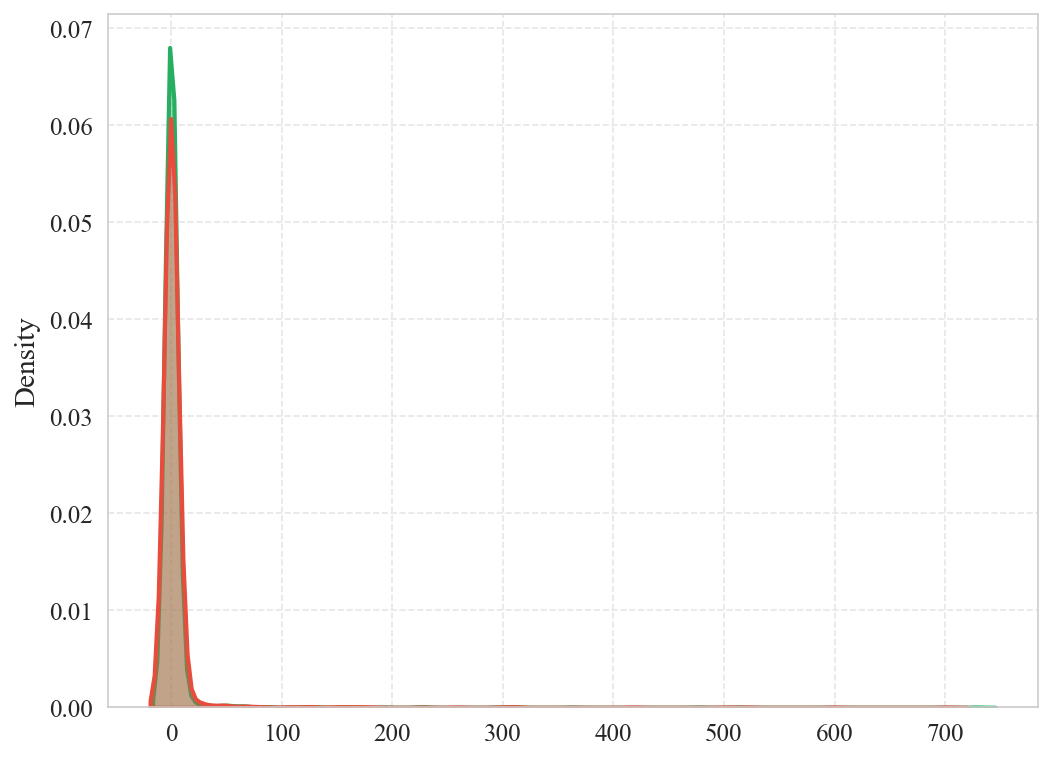

In [136]:
print("Mean violation score:")
print("  Secure:", secure_scores.mean())
print("  Vulnerable:", vuln_scores.mean())
print("  Δ:", delta_scores.mean())
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6), dpi=150)
sns.kdeplot(secure_scores, color='#27AE60', fill=True, alpha=0.4,
            label=f'Secure (n={len(secure_scores)})', linewidth=2)
sns.kdeplot(vuln_scores, color='#E74C3C', fill=True, alpha=0.4,
            label=f'Vulnerable (n={len(vuln_scores)})', linewidth=2)



In [146]:
from scipy.stats import wilcoxon

stat, p = wilcoxon(delta_scores)
print("Wilcoxon signed-rank p:", p)
p_pos = np.mean(delta_scores > 0)
print("P(Δ > 0):", p_pos)

Wilcoxon signed-rank p: 0.004083885070636835
P(Δ > 0): 0.0188527878058564


## Dump

In [ ]:
# import numpy as np
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# def plot_pca_subplots(cwe_data_map: Dict[str, VulnerabilityData]):
#     """Create subplots for each CWE"""
#     n_cwes = len(cwe_data_map)
#     n_cols = 3
#     n_rows = (n_cwes + n_cols - 1) // n_cols
    
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
#     axes = axes.flatten() if n_cwes > 1 else [axes]
    
#     for idx, (cwe, data) in enumerate(cwe_data_map.items()):
#         pca = PCA(n_components=2)
        
#         # Fit PCA on combined data
#         combined_data = torch.cat([data.vulnerable, data.secure], dim=0).numpy()
#         pca_transformed = pca.fit_transform(combined_data)
        
#         # Split back into vulnerable and safe
#         vuln_size = data.vulnerable.shape[0]
#         vuln_pca = pca_transformed[:vuln_size]
#         safe_pca = pca_transformed[vuln_size:]
        
#         ax = axes[idx]
#         ax.scatter(
#             vuln_pca[:, 0],
#             vuln_pca[:, 1],
#             c="red",
#             label="Vulnerable",
#             alpha=0.7,
#         )
#         ax.scatter(
#             safe_pca[:, 0],
#             safe_pca[:, 1],
#             c="blue",
#             label="Safe",
#             alpha=0.7,
#         )
#         ax.set_xlabel("PCA Component 1")
#         ax.set_ylabel("PCA Component 2")
#         ax.set_title(f"{cwe}")
#         ax.legend()
    
#     # Hide unused subplots
#     for idx in range(n_cwes, len(axes)):
#         axes[idx].axis('off')
    
#     plt.suptitle("PCA of Sparse Autoencoder Activations by CWE", fontsize=16, y=1.00)
#     plt.tight_layout()
#     plt.show()


# # Plot subplots for each CWE
# print("Plotting PCA subplots for each CWE")
# plot_pca_subplots(cwe_tensor_map)


Claude


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from typing import Dict, Any

def measure_activation_distribution(activations: torch.Tensor, name: str = "Activations") -> Dict[str, Any]:
    """
    Comprehensive measurement of activation distribution statistics.
    
    Args:
        activations: Tensor of shape (n_samples, n_features)
        name: Name for the distribution (e.g., "Secure", "Vulnerable")
    
    Returns:
        Dictionary containing distribution statistics
    """
    activations_np = activations.numpy()
    
    # Flatten for overall statistics
    flat_activations = activations_np.flatten()
    
    # Sparsity analysis
    threshold = 1e-6
    sparsity = (np.abs(flat_activations) < threshold).sum() / flat_activations.size
    
    # Basic statistics
    stats_dict = {
        "name": name,
        "n_samples": activations.shape[0],
        "n_features": activations.shape[1],
        # Overall statistics
        "mean": float(np.mean(flat_activations)),
        "std": float(np.std(flat_activations)),
        "median": float(np.median(flat_activations)),
        "min": float(np.min(flat_activations)),
        "max": float(np.max(flat_activations)),
        # Distribution shape
        "skewness": float(stats.skew(flat_activations)),
        "kurtosis": float(stats.kurtosis(flat_activations)),
        # Sparsity
        "sparsity": float(sparsity),
        "active_ratio": float(1 - sparsity),
        # Percentiles
        "p25": float(np.percentile(flat_activations, 25)),
        "p75": float(np.percentile(flat_activations, 75)),
        "p95": float(np.percentile(flat_activations, 95)),
        "p99": float(np.percentile(flat_activations, 99)),
        # Per-feature statistics
        "mean_per_feature": np.mean(activations_np, axis=0),
        "std_per_feature": np.std(activations_np, axis=0),
        "max_per_feature": np.max(activations_np, axis=0),
        # Top activated features
        "top_10_features": np.argsort(np.mean(activations_np, axis=0))[-10:][::-1],
        "top_10_values": np.sort(np.mean(activations_np, axis=0))[-10:][::-1],
    }
    
    return stats_dict


def plot_activation_distribution(secure_activations: torch.Tensor, 
                                 vulnerable_activations: torch.Tensor = None,
                                 figsize=(16, 12)):
    """
    Create comprehensive visualization of activation distributions.
    
    Args:
        secure_activations: Tensor of secure code activations
        vulnerable_activations: Optional tensor of vulnerable code activations for comparison
    """
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    fig.suptitle('Activation Distribution Analysis', fontsize=16, y=1.00)
    
    secure_flat = secure_activations.numpy().flatten()
    
    # 1. Overall histogram
    ax = axes[0, 0]
    ax.hist(secure_flat, bins=100, alpha=0.7, label='Secure', color='green', density=True)
    if vulnerable_activations is not None:
        vuln_flat = vulnerable_activations.numpy().flatten()
        ax.hist(vuln_flat, bins=100, alpha=0.7, label='Vulnerable', color='red', density=True)
    ax.set_xlabel('Activation Value')
    ax.set_ylabel('Density')
    ax.set_title('Overall Distribution')
    ax.legend()
    ax.set_yscale('log')
    
    # 2. Distribution without zeros (non-sparse activations)
    ax = axes[0, 1]
    secure_nonzero = secure_flat[np.abs(secure_flat) > 1e-6]
    ax.hist(secure_nonzero, bins=100, alpha=0.7, label='Secure (non-zero)', color='green', density=True)
    if vulnerable_activations is not None:
        vuln_nonzero = vuln_flat[np.abs(vuln_flat) > 1e-6]
        ax.hist(vuln_nonzero, bins=100, alpha=0.7, label='Vulnerable (non-zero)', color='red', density=True)
    ax.set_xlabel('Activation Value')
    ax.set_ylabel('Density')
    ax.set_title('Non-Zero Activations')
    ax.legend()
    
    # 3. KDE plot
    ax = axes[0, 2]
    sns.kdeplot(secure_flat, ax=ax, label='Secure', color='green', warn_singular=False)
    if vulnerable_activations is not None:
        sns.kdeplot(vuln_flat, ax=ax, label='Vulnerable', color='red', warn_singular=False)
    ax.set_xlabel('Activation Value')
    ax.set_ylabel('Density')
    ax.set_title('Kernel Density Estimate')
    ax.legend()
    
    # 4. Q-Q plot (normality test)
    ax = axes[1, 0]
    stats.probplot(secure_flat[::100], dist="norm", plot=ax)  # Subsample for speed
    ax.set_title('Q-Q Plot (Secure)')
    
    # 5. Box plot comparison
    ax = axes[1, 1]
    if vulnerable_activations is not None:
        data_to_plot = [secure_flat[::100], vuln_flat[::100]]  # Subsample
        ax.boxplot(data_to_plot, labels=['Secure', 'Vulnerable'])
    else:
        ax.boxplot([secure_flat[::100]], labels=['Secure'])
    ax.set_ylabel('Activation Value')
    ax.set_title('Box Plot Comparison')
    
    # 6. Sparsity comparison
    ax = axes[1, 2]
    secure_sparsity = (np.abs(secure_flat) < 1e-6).sum() / secure_flat.size * 100
    if vulnerable_activations is not None:
        vuln_sparsity = (np.abs(vuln_flat) < 1e-6).sum() / vuln_flat.size * 100
        ax.bar(['Secure', 'Vulnerable'], [secure_sparsity, vuln_sparsity], 
               color=['green', 'red'], alpha=0.7)
    else:
        ax.bar(['Secure'], [secure_sparsity], color=['green'], alpha=0.7)
    ax.set_ylabel('Sparsity (%)')
    ax.set_title('Activation Sparsity')
    ax.set_ylim([0, 100])
    
    # 7. Mean activation per feature (top features)
    ax = axes[2, 0]
    mean_per_feature = np.mean(secure_activations.numpy(), axis=0)
    top_n = 50
    top_indices = np.argsort(mean_per_feature)[-top_n:]
    ax.bar(range(top_n), mean_per_feature[top_indices], color='green', alpha=0.7)
    ax.set_xlabel('Feature Index (sorted)')
    ax.set_ylabel('Mean Activation')
    ax.set_title(f'Top {top_n} Most Activated Features (Secure)')
    
    # 8. Activation magnitude distribution
    ax = axes[2, 1]
    secure_magnitudes = np.linalg.norm(secure_activations.numpy(), axis=1)
    ax.hist(secure_magnitudes, bins=50, alpha=0.7, label='Secure', color='green', density=True)
    if vulnerable_activations is not None:
        vuln_magnitudes = np.linalg.norm(vulnerable_activations.numpy(), axis=1)
        ax.hist(vuln_magnitudes, bins=50, alpha=0.7, label='Vulnerable', color='red', density=True)
    ax.set_xlabel('L2 Norm')
    ax.set_ylabel('Density')
    ax.set_title('Activation Vector Magnitude')
    ax.legend()
    
    # 9. Cumulative distribution
    ax = axes[2, 2]
    secure_sorted = np.sort(np.abs(secure_flat))
    cumsum_secure = np.cumsum(secure_sorted)
    cumsum_secure = cumsum_secure / cumsum_secure[-1]
    ax.plot(np.linspace(0, 100, len(cumsum_secure)), cumsum_secure, 
            label='Secure', color='green', linewidth=2)
    if vulnerable_activations is not None:
        vuln_sorted = np.sort(np.abs(vuln_flat))
        cumsum_vuln = np.cumsum(vuln_sorted)
        cumsum_vuln = cumsum_vuln / cumsum_vuln[-1]
        ax.plot(np.linspace(0, 100, len(cumsum_vuln)), cumsum_vuln, 
                label='Vulnerable', color='red', linewidth=2)
    ax.set_xlabel('Percentile (%)')
    ax.set_ylabel('Cumulative Sum (normalized)')
    ax.set_title('Cumulative Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def print_distribution_stats(stats_dict: Dict[str, Any]):
    """Pretty print distribution statistics."""
    print(f"\n{'='*60}")
    print(f"  {stats_dict['name']} Activation Distribution Statistics")
    print(f"{'='*60}")
    print(f"Dataset Size:")
    print(f"  Samples: {stats_dict['n_samples']:,}")
    print(f"  Features: {stats_dict['n_features']:,}")
    print(f"\nBasic Statistics:")
    print(f"  Mean:   {stats_dict['mean']:>10.6f}")
    print(f"  Std:    {stats_dict['std']:>10.6f}")
    print(f"  Median: {stats_dict['median']:>10.6f}")
    print(f"  Min:    {stats_dict['min']:>10.6f}")
    print(f"  Max:    {stats_dict['max']:>10.6f}")
    print(f"\nDistribution Shape:")
    print(f"  Skewness: {stats_dict['skewness']:>8.4f}")
    print(f"  Kurtosis: {stats_dict['kurtosis']:>8.4f}")
    print(f"\nSparsity:")
    print(f"  Sparsity:     {stats_dict['sparsity']*100:>6.2f}%")
    print(f"  Active Ratio: {stats_dict['active_ratio']*100:>6.2f}%")
    print(f"\nPercentiles:")
    print(f"  25th: {stats_dict['p25']:>10.6f}")
    print(f"  75th: {stats_dict['p75']:>10.6f}")
    print(f"  95th: {stats_dict['p95']:>10.6f}")
    print(f"  99th: {stats_dict['p99']:>10.6f}")
    print(f"\nTop 10 Most Activated Features:")
    for i, (feat_idx, feat_val) in enumerate(zip(stats_dict['top_10_features'], 
                                                   stats_dict['top_10_values'])):
        print(f"  {i+1}. Feature {feat_idx:>5d}: {feat_val:>10.6f}")
    print(f"{'='*60}\n")


# Load secure activations and analyze
print("Loading secure activations...")
secure_activations = torch.load(f"../artifacts/activations/{RUN_ID}/safe_layer_0.pt")
vulnerable_activations = torch.load(f"../artifacts/activations/{RUN_ID}/vulnerable_layer_0.pt")

print(f"Secure shape: {secure_activations.shape}")
print(f"Vulnerable shape: {vulnerable_activations.shape}")

# Measure distributions
secure_stats = measure_activation_distribution(secure_activations, "Secure Code")
vulnerable_stats = measure_activation_distribution(vulnerable_activations, "Vulnerable Code")

# Print statistics
print_distribution_stats(secure_stats)
print_distribution_stats(vulnerable_stats)

# Visualize
plot_activation_distribution(secure_activations, vulnerable_activations)

In [ ]:
from scipy.stats import ks_2samp, mannwhitneyu, wasserstein_distance
import json

def compare_distributions(secure_stats: Dict, vulnerable_stats: Dict) -> Dict[str, Any]:
    """
    Statistical comparison between secure and vulnerable code distributions.
    """
    print(f"\n{'='*60}")
    print(f"  Distribution Comparison: Secure vs Vulnerable")
    print(f"{'='*60}")
    
    # Difference in basic statistics
    print("\nDifference in Basic Statistics (Vulnerable - Secure):")
    print(f"  Mean Difference:   {vulnerable_stats['mean'] - secure_stats['mean']:>10.6f}")
    print(f"  Std Difference:    {vulnerable_stats['std'] - secure_stats['std']:>10.6f}")
    print(f"  Median Difference: {vulnerable_stats['median'] - secure_stats['median']:>10.6f}")
    
    # Relative differences
    print("\nRelative Differences (%):")
    rel_mean = ((vulnerable_stats['mean'] - secure_stats['mean']) / (abs(secure_stats['mean']) + 1e-10)) * 100
    rel_std = ((vulnerable_stats['std'] - secure_stats['std']) / (abs(secure_stats['std']) + 1e-10)) * 100
    rel_sparsity = ((vulnerable_stats['sparsity'] - secure_stats['sparsity']) / (secure_stats['sparsity'] + 1e-10)) * 100
    
    print(f"  Mean:     {rel_mean:>8.2f}%")
    print(f"  Std:      {rel_std:>8.2f}%")
    print(f"  Sparsity: {rel_sparsity:>8.2f}%")
    
    # Distribution shape comparison
    print("\nDistribution Shape Comparison:")
    print(f"  Skewness Difference: {vulnerable_stats['skewness'] - secure_stats['skewness']:>8.4f}")
    print(f"  Kurtosis Difference: {vulnerable_stats['kurtosis'] - secure_stats['kurtosis']:>8.4f}")
    
    # Sparsity comparison
    print("\nSparsity Comparison:")
    print(f"  Secure Sparsity:     {secure_stats['sparsity']*100:>6.2f}%")
    print(f"  Vulnerable Sparsity: {vulnerable_stats['sparsity']*100:>6.2f}%")
    print(f"  Difference:          {(vulnerable_stats['sparsity'] - secure_stats['sparsity'])*100:>6.2f}%")
    
    print(f"{'='*60}\n")
    
    return {
        "mean_diff": vulnerable_stats['mean'] - secure_stats['mean'],
        "std_diff": vulnerable_stats['std'] - secure_stats['std'],
        "median_diff": vulnerable_stats['median'] - secure_stats['median'],
        "sparsity_diff": vulnerable_stats['sparsity'] - secure_stats['sparsity'],
        "skewness_diff": vulnerable_stats['skewness'] - secure_stats['skewness'],
        "kurtosis_diff": vulnerable_stats['kurtosis'] - secure_stats['kurtosis'],
        "rel_mean_diff_pct": rel_mean,
        "rel_std_diff_pct": rel_std,
        "rel_sparsity_diff_pct": rel_sparsity,
    }


def statistical_tests(secure_activations: torch.Tensor, vulnerable_activations: torch.Tensor):
    """
    Perform statistical tests to compare distributions.
    """
    secure_flat = secure_activations.numpy().flatten()
    vuln_flat = vulnerable_activations.numpy().flatten()
    
    # Subsample for computational efficiency
    sample_size = min(100000, len(secure_flat), len(vuln_flat))
    secure_sample = np.random.choice(secure_flat, size=sample_size, replace=False)
    vuln_sample = np.random.choice(vuln_flat, size=sample_size, replace=False)
    
    print(f"\n{'='*60}")
    print(f"  Statistical Tests (Secure vs Vulnerable)")
    print(f"{'='*60}")
    print(f"Sample size: {sample_size:,} activations\n")
    
    # Kolmogorov-Smirnov test
    ks_stat, ks_pval = ks_2samp(secure_sample, vuln_sample)
    print("Kolmogorov-Smirnov Test:")
    print(f"  Statistic: {ks_stat:.6f}")
    print(f"  P-value:   {ks_pval:.6e}")
    print(f"  Result:    {'Distributions are DIFFERENT' if ks_pval < 0.05 else 'Distributions are SIMILAR'} (α=0.05)")
    
    # Mann-Whitney U test
    mw_stat, mw_pval = mannwhitneyu(secure_sample, vuln_sample, alternative='two-sided')
    print("\nMann-Whitney U Test:")
    print(f"  Statistic: {mw_stat:.6f}")
    print(f"  P-value:   {mw_pval:.6e}")
    print(f"  Result:    {'Medians are DIFFERENT' if mw_pval < 0.05 else 'Medians are SIMILAR'} (α=0.05)")
    
    # Wasserstein distance (Earth Mover's Distance)
    # Subsample more aggressively for Wasserstein
    ws_sample_size = min(10000, len(secure_flat), len(vuln_flat))
    secure_ws = np.random.choice(secure_flat, size=ws_sample_size, replace=False)
    vuln_ws = np.random.choice(vuln_flat, size=ws_sample_size, replace=False)
    ws_dist = wasserstein_distance(secure_ws, vuln_ws)
    print("\nWasserstein Distance (Earth Mover's Distance):")
    print(f"  Distance: {ws_dist:.6f}")
    print(f"  Interpretation: {'Large' if ws_dist > 0.1 else 'Small'} distributional difference")
    
    print(f"{'='*60}\n")
    
    return {
        "ks_statistic": ks_stat,
        "ks_pvalue": ks_pval,
        "mw_statistic": mw_stat,
        "mw_pvalue": mw_pval,
        "wasserstein_distance": ws_dist,
    }


def feature_wise_analysis(secure_activations: torch.Tensor, vulnerable_activations: torch.Tensor, top_n: int = 20):
    """
    Analyze which features differ most between secure and vulnerable code.
    """
    secure_mean = np.mean(secure_activations.numpy(), axis=0)
    vuln_mean = np.mean(vulnerable_activations.numpy(), axis=0)
    
    # Absolute difference
    diff = vuln_mean - secure_mean
    abs_diff = np.abs(diff)
    
    # Get top differentiating features
    top_indices = np.argsort(abs_diff)[-top_n:][::-1]
    
    print(f"\n{'='*60}")
    print(f"  Top {top_n} Most Differentiating Features")
    print(f"{'='*60}")
    print(f"{'Feature':<10} {'Secure':>12} {'Vulnerable':>12} {'Difference':>12} {'%Change':>10}")
    print(f"{'-'*60}")
    
    for idx in top_indices:
        pct_change = ((vuln_mean[idx] - secure_mean[idx]) / (abs(secure_mean[idx]) + 1e-10)) * 100
        print(f"{idx:<10} {secure_mean[idx]:>12.6f} {vuln_mean[idx]:>12.6f} {diff[idx]:>12.6f} {pct_change:>9.2f}%")
    
    print(f"{'='*60}\n")
    
    # Plot top differentiating features
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot of differences
    ax1.barh(range(top_n), abs_diff[top_indices], color='purple', alpha=0.7)
    ax1.set_yticks(range(top_n))
    ax1.set_yticklabels([f"Feature {i}" for i in top_indices])
    ax1.set_xlabel('Absolute Difference in Mean Activation')
    ax1.set_title(f'Top {top_n} Differentiating Features')
    ax1.invert_yaxis()
    
    # Comparison plot
    x = np.arange(top_n)
    width = 0.35
    ax2.barh(x - width/2, secure_mean[top_indices], width, label='Secure', color='green', alpha=0.7)
    ax2.barh(x + width/2, vuln_mean[top_indices], width, label='Vulnerable', color='red', alpha=0.7)
    ax2.set_yticks(x)
    ax2.set_yticklabels([f"Feature {i}" for i in top_indices])
    ax2.set_xlabel('Mean Activation')
    ax2.set_title('Feature Comparison: Secure vs Vulnerable')
    ax2.legend()
    ax2.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    return {
        "top_features": top_indices.tolist(),
        "differences": diff[top_indices].tolist(),
        "secure_means": secure_mean[top_indices].tolist(),
        "vulnerable_means": vuln_mean[top_indices].tolist(),
    }


# Run comparison analyses
comparison_results = compare_distributions(secure_stats, vulnerable_stats)
test_results = statistical_tests(secure_activations, vulnerable_activations)
feature_results = feature_wise_analysis(secure_activations, vulnerable_activations, top_n=20)

# Save all results to JSON
results_summary = {
    "run_id": RUN_ID,
    "layer": 0,
    "secure_stats": {k: v for k, v in secure_stats.items() if not isinstance(v, np.ndarray)},
    "vulnerable_stats": {k: v for k, v in vulnerable_stats.items() if not isinstance(v, np.ndarray)},
    "comparison": comparison_results,
    "statistical_tests": test_results,
    "feature_analysis": feature_results,
}

output_file = f"../artifacts/activations/{RUN_ID}/distribution_analysis.json"
with open(output_file, "w") as f:
    json.dump(results_summary, f, indent=2)

print(f"Results saved to: {output_file}")

## Step 1: Define Secure Activation Ranges (Invariants)

### Proper Feature Classification and Violation Detection

**Step A — Classify features by activation frequency**

For each feature `i`, compute:
```
p_i = P(z_i > ε)  on secure data
```

Then split:
- **Active features**: `p_i ≥ 10-15%` (fires often enough to model a range)
- **Dormant features**: `p_i < 10-15%` (rarely fires, no range to model)

**Step B — Redefine violations**

For **ACTIVE** features:
```
violation_i = |z_i − median_i| / MAD_i
```

For **DORMANT** features:
- Do NOT use MAD
- Define: `activation_violation_i = 1 if z_i > θ_i`
- Where `θ_i` is a high secure percentile (e.g., 99.9%) or a fixed small ε

**Step C — Compute per-sample scores separately**

For each sample compute:
1. **Range Violation Score** (active features only)
2. **Activation Violation Count** (dormant features only)

Then compare secure vs vulnerable distributions.

In [ ]:
from dataclasses import dataclass
from typing import Optional, Tuple
from enum import Enum
import pickle
from tqdm import tqdm
import numpy as np
import torch
import matplotlib.pyplot as plt

secure_activations = all_safe_features["layer_0"]
vulnerable_activations = all_vulnerable_features["layer_0"]

class FeatureType(Enum):
    """Classification based on activation frequency p_i = P(z_i > ε)."""
    ACTIVE = "active"      # p_i >= 10%: fires often, model with range
    DORMANT = "dormant"    # p_i < 10%: rarely fires, flag any activation


@dataclass
class FeatureInvariant:
    """Invariant for a single SAE feature."""
    feature_idx: int
    feature_type: FeatureType
    activation_freq: float  # p_i = P(z_i > ε) on secure data
    
    # For ACTIVE features: range statistics
    median: Optional[float] = None
    mad: Optional[float] = None
    q1: Optional[float] = None
    q3: Optional[float] = None
    iqr: Optional[float] = None
    
    # For DORMANT features: activation threshold
    activation_threshold: float = 0.0  # θ_i: 99.9th percentile of secure activations
    
    def is_range_violation(self, value: float, k: float = 3.0) -> bool:
        """
        Check if value violates the range invariant (ACTIVE features only).
        Returns False for DORMANT features.
        """
        if self.feature_type != FeatureType.ACTIVE:
            return False
        if self.mad is None or self.mad == 0:
            return False
        lower = self.median - k * self.mad
        upper = self.median + k * self.mad
        return value < lower or value > upper
    
    def is_activation_violation(self, value: float) -> bool:
        """
        Check if value violates the dormancy invariant (DORMANT features only).
        Returns True if a dormant feature fires above its threshold.
        """
        if self.feature_type != FeatureType.DORMANT:
            return False
        return value > self.activation_threshold
    
    def range_violation_score(self, value: float) -> float:
        """
        Compute |z - median| / MAD for ACTIVE features.
        Returns 0 for DORMANT features.
        """
        if self.feature_type != FeatureType.ACTIVE:
            return 0.0
        if self.mad is None or self.mad == 0:
            return 0.0
        return abs(value - self.median) / self.mad


def compute_mad(values: np.ndarray) -> float:
    """Compute Median Absolute Deviation."""
    median = np.median(values)
    return np.median(np.abs(values - median))


def compute_feature_invariants(
    secure_activations: torch.Tensor,
    activation_freq_threshold: float = 0.10,  # 10% threshold
    noise_epsilon: float = 1e-6,
    dormant_percentile: float = 99.9,
) -> list[FeatureInvariant]:
    """
    Compute feature invariants based on secure code activations.
    
    Step A: Classify by activation frequency p_i = P(z_i > ε)
    Step B: Compute appropriate statistics for each type
    
    Args:
        secure_activations: Tensor of shape (n_samples, n_features)
        activation_freq_threshold: Features with p_i >= this are ACTIVE
        noise_epsilon: Threshold for "active" (non-zero) activation
        dormant_percentile: Percentile for dormant activation threshold
    """
    secure_np = secure_activations.numpy()
    n_samples, n_features = secure_np.shape
    
    invariants = []
    
    print(f"Computing feature invariants for {n_features} features...")
    print(f"  Activation frequency threshold: {activation_freq_threshold*100:.0f}%")
    print(f"  Noise epsilon: {noise_epsilon}")
    print(f"  Dormant threshold percentile: {dormant_percentile}")
    
    for i in tqdm(range(n_features), desc="Processing features"):
        feature_values = secure_np[:, i]
        
        # Step A: Compute activation frequency p_i = P(z_i > ε)
        activation_freq = (feature_values > noise_epsilon).sum() / n_samples
        
        # Classify feature
        if activation_freq >= activation_freq_threshold:
            feature_type = FeatureType.ACTIVE
        else:
            feature_type = FeatureType.DORMANT
        
        # Step B: Compute type-specific statistics
        if feature_type == FeatureType.ACTIVE:
            # Active features: compute range statistics on all values
            median = np.median(feature_values)
            mad = compute_mad(feature_values)
            q1 = np.percentile(feature_values, 25)
            q3 = np.percentile(feature_values, 75)
            iqr = q3 - q1
            activation_threshold = 0.0  # Not used for active features
            
            invariants.append(FeatureInvariant(
                feature_idx=i,
                feature_type=feature_type,
                activation_freq=activation_freq,
                median=median,
                mad=mad,
                q1=q1,
                q3=q3,
                iqr=iqr,
                activation_threshold=activation_threshold,
            ))
        else:
            # Dormant features: compute activation threshold θ_i
            # Use high percentile (99.9%) of all values as threshold
            activation_threshold = np.percentile(feature_values, dormant_percentile)
            
            invariants.append(FeatureInvariant(
                feature_idx=i,
                feature_type=feature_type,
                activation_freq=activation_freq,
                activation_threshold=activation_threshold,
            ))
    
    return invariants


@dataclass
class SampleViolationScores:
    """Violation scores for a single sample."""
    # Active feature violations
    range_violation_score: float  # Sum of |z - median| / MAD for active features
    range_violation_count: int    # Number of active features outside k*MAD
    n_active_features: int
    
    # Dormant feature violations
    activation_violation_count: int  # Number of dormant features that fired
    n_dormant_features: int
    
    # Per-feature details (for analysis)
    active_violations: list[int] = None    # Indices of violated active features
    dormant_violations: list[int] = None   # Indices of violated dormant features


def compute_sample_violations(
    sample: np.ndarray,
    invariants: list[FeatureInvariant],
    k: float = 3.0,
) -> SampleViolationScores:
    """
    Compute violation scores for a single sample.
    
    Args:
        sample: 1D array of activations
        invariants: List of FeatureInvariant objects
        k: MAD multiplier for range violations
    """
    range_violation_score = 0.0
    range_violation_count = 0
    activation_violation_count = 0
    
    n_active = 0
    n_dormant = 0
    
    active_violations = []
    dormant_violations = []
    
    for inv in invariants:
        value = sample[inv.feature_idx]
        
        if inv.feature_type == FeatureType.ACTIVE:
            n_active += 1
            # Compute range violation score
            score = inv.range_violation_score(value)
            range_violation_score += score
            
            # Check if it's a violation (outside k*MAD)
            if inv.is_range_violation(value, k):
                range_violation_count += 1
                active_violations.append(inv.feature_idx)
        
        else:  # DORMANT
            n_dormant += 1
            # Check if dormant feature activated
            if inv.is_activation_violation(value):
                activation_violation_count += 1
                dormant_violations.append(inv.feature_idx)
    
    return SampleViolationScores(
        range_violation_score=range_violation_score,
        range_violation_count=range_violation_count,
        n_active_features=n_active,
        activation_violation_count=activation_violation_count,
        n_dormant_features=n_dormant,
        active_violations=active_violations,
        dormant_violations=dormant_violations,
    )


def analyze_population(
    activations: torch.Tensor,
    invariants: list[FeatureInvariant],
    k: float = 3.0,
    label: str = "Population",
) -> list[SampleViolationScores]:
    """Compute violation scores for all samples in a population."""
    act_np = activations.numpy()
    scores = []
    
    for sample in tqdm(act_np, desc=f"Analyzing {label}"):
        scores.append(compute_sample_violations(sample, invariants, k))
    
    return scores


# ============================================================================
# RUN ANALYSIS
# ============================================================================

print("="*70)
print("STEP A: Computing Feature Invariants")
print("="*70)

# Compute invariants with 10% activation frequency threshold
invariants = compute_feature_invariants(
    secure_activations,
    activation_freq_threshold=0.10,  # 10%
    noise_epsilon=1e-6,
    dormant_percentile=99.9,
)

# Summary statistics
n_active = sum(1 for inv in invariants if inv.feature_type == FeatureType.ACTIVE)
n_dormant = sum(1 for inv in invariants if inv.feature_type == FeatureType.DORMANT)

print(f"\n{'='*70}")
print(f"Feature Classification Results")
print(f"{'='*70}")
print(f"Total features: {len(invariants)}")
print(f"  ACTIVE (p_i >= 10%):  {n_active:>5} ({n_active/len(invariants)*100:.1f}%)")
print(f"  DORMANT (p_i < 10%):  {n_dormant:>5} ({n_dormant/len(invariants)*100:.1f}%)")

# Active feature statistics
active_freqs = [inv.activation_freq for inv in invariants if inv.feature_type == FeatureType.ACTIVE]
active_mads = [inv.mad for inv in invariants if inv.feature_type == FeatureType.ACTIVE and inv.mad > 0]

print(f"\nACTIVE Features:")
print(f"  Activation freq: {np.mean(active_freqs)*100:.1f}% ± {np.std(active_freqs)*100:.1f}%")
print(f"  MAD: {np.mean(active_mads):.6f} ± {np.std(active_mads):.6f}")

# Dormant feature statistics  
dormant_freqs = [inv.activation_freq for inv in invariants if inv.feature_type == FeatureType.DORMANT]
dormant_thresholds = [inv.activation_threshold for inv in invariants if inv.feature_type == FeatureType.DORMANT]

print(f"\nDORMANT Features:")
print(f"  Activation freq: {np.mean(dormant_freqs)*100:.2f}% ± {np.std(dormant_freqs)*100:.2f}%")
print(f"  Threshold (99.9%): {np.mean(dormant_thresholds):.6f} ± {np.std(dormant_thresholds):.6f}")

# Save invariants
output_path = f"../artifacts/activations/{RUN_ID}/feature_invariants_layer_0.pkl"
with open(output_path, 'wb') as f:
    pickle.dump(invariants, f)
print(f"\nInvariants saved to: {output_path}")

# ============================================================================
# Visualization
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Classification Analysis', fontsize=16)

# 1. Feature type distribution
ax = axes[0, 0]
ax.bar(['Active\n(p ≥ 10%)', 'Dormant\n(p < 10%)'], [n_active, n_dormant], 
       color=['green', 'red'], alpha=0.7)
ax.set_ylabel('Count')
ax.set_title('Feature Type Distribution')
ax.grid(True, alpha=0.3, axis='y')

# 2. Activation frequency distribution
ax = axes[0, 1]
all_freqs = [inv.activation_freq * 100 for inv in invariants]
ax.hist(all_freqs, bins=100, alpha=0.7, color='blue', edgecolor='black')
ax.axvline(10, color='red', linestyle='--', linewidth=2, label='10% threshold')
ax.set_xlabel('Activation Frequency (%)')
ax.set_ylabel('Count')
ax.set_title('Activation Frequency Distribution')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. MAD distribution for active features
ax = axes[1, 0]
if active_mads:
    ax.hist(active_mads, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax.set_xlabel('MAD')
    ax.set_ylabel('Count')
    ax.set_title(f'MAD Distribution (Active Features, n={len(active_mads)})')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

# 4. Threshold distribution for dormant features
ax = axes[1, 1]
ax.hist(dormant_thresholds, bins=50, alpha=0.7, color='red', edgecolor='black')
ax.set_xlabel('Activation Threshold (99.9th percentile)')
ax.set_ylabel('Count')
ax.set_title(f'Dormant Thresholds (n={len(dormant_thresholds)})')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# STEP C: Compare Secure vs Vulnerable Populations
# ============================================================================

print("="*70)
print("STEP C: Computing Per-Sample Violation Scores")
print("="*70)

# Analyze both populations
k_mad = 3.0  # MAD multiplier for range violations

secure_scores = analyze_population(secure_activations, invariants, k=k_mad, label="Secure")
vuln_scores = analyze_population(vulnerable_activations, invariants, k=k_mad, label="Vulnerable")

# Extract metrics
secure_range_scores = [s.range_violation_score for s in secure_scores]
vuln_range_scores = [s.range_violation_score for s in vuln_scores]

secure_range_counts = [s.range_violation_count for s in secure_scores]
vuln_range_counts = [s.range_violation_count for s in vuln_scores]

secure_activation_counts = [s.activation_violation_count for s in secure_scores]
vuln_activation_counts = [s.activation_violation_count for s in vuln_scores]

# Print comparison
print(f"\n{'='*70}")
print(f"Population Comparison: Secure vs Vulnerable")
print(f"{'='*70}")

print(f"\n1. RANGE VIOLATION SCORE (Active Features, k={k_mad})")
print(f"   Sum of |z - median| / MAD across active features")
print(f"   Secure:     {np.mean(secure_range_scores):>8.2f} ± {np.std(secure_range_scores):>7.2f}")
print(f"   Vulnerable: {np.mean(vuln_range_scores):>8.2f} ± {np.std(vuln_range_scores):>7.2f}")
print(f"   Difference: {np.mean(vuln_range_scores) - np.mean(secure_range_scores):>+8.2f}")

print(f"\n2. RANGE VIOLATION COUNT (Active Features outside {k_mad}σ)")
print(f"   Number of active features with |z - median| > k*MAD")
print(f"   Secure:     {np.mean(secure_range_counts):>8.2f} ± {np.std(secure_range_counts):>7.2f}")
print(f"   Vulnerable: {np.mean(vuln_range_counts):>8.2f} ± {np.std(vuln_range_counts):>7.2f}")
print(f"   Difference: {np.mean(vuln_range_counts) - np.mean(secure_range_counts):>+8.2f}")

print(f"\n3. ACTIVATION VIOLATION COUNT (Dormant Features)")
print(f"   Number of dormant features that fired above θ (99.9th percentile)")
print(f"   Secure:     {np.mean(secure_activation_counts):>8.2f} ± {np.std(secure_activation_counts):>7.2f}")
print(f"   Vulnerable: {np.mean(vuln_activation_counts):>8.2f} ± {np.std(vuln_activation_counts):>7.2f}")
print(f"   Difference: {np.mean(vuln_activation_counts) - np.mean(secure_activation_counts):>+8.2f}")

print(f"{'='*70}\n")

In [ ]:

# ============================================================================
# Statistical Tests
# ============================================================================
from scipy.stats import mannwhitneyu, ks_2samp

print("Statistical Tests (Mann-Whitney U):")

# Range violation score
stat, pval = mannwhitneyu(secure_range_scores, vuln_range_scores, alternative='two-sided')
print(f"  Range Violation Score: U={stat:.0f}, p={pval:.2e} {'***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''}")

# Range violation count
stat, pval = mannwhitneyu(secure_range_counts, vuln_range_counts, alternative='two-sided')
print(f"  Range Violation Count: U={stat:.0f}, p={pval:.2e} {'***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''}")

# Activation violation count
stat, pval = mannwhitneyu(secure_activation_counts, vuln_activation_counts, alternative='two-sided')
print(f"  Activation Violation Count: U={stat:.0f}, p={pval:.2e} {'***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''}")

# ============================================================================
# Visualization
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Secure vs Vulnerable: Violation Score Comparison', fontsize=16)

# 1. Range Violation Score Distribution
ax = axes[0, 0]
ax.hist(secure_range_scores, bins=50, alpha=0.7, label='Secure', color='green', density=True)
ax.hist(vuln_range_scores, bins=50, alpha=0.7, label='Vulnerable', color='red', density=True)
ax.set_xlabel('Range Violation Score')
ax.set_ylabel('Density')
ax.set_title('Range Violation Score\n(Active Features)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Range Violation Count Distribution
ax = axes[0, 1]
ax.hist(secure_range_counts, bins=30, alpha=0.7, label='Secure', color='green', density=True)
ax.hist(vuln_range_counts, bins=30, alpha=0.7, label='Vulnerable', color='red', density=True)
ax.set_xlabel('Range Violation Count')
ax.set_ylabel('Density')
ax.set_title(f'Range Violations (k={k_mad})\n(Active Features)')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Activation Violation Count Distribution
ax = axes[0, 2]
ax.hist(secure_activation_counts, bins=30, alpha=0.7, label='Secure', color='green', density=True)
ax.hist(vuln_activation_counts, bins=30, alpha=0.7, label='Vulnerable', color='red', density=True)
ax.set_xlabel('Activation Violation Count')
ax.set_ylabel('Density')
ax.set_title('Dormant Feature Activations\n(Dormant Features)')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Box plot comparison
ax = axes[1, 0]
data = [secure_range_scores, vuln_range_scores]
bp = ax.boxplot(data, labels=['Secure', 'Vulnerable'], patch_artist=True)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.7)
ax.set_ylabel('Range Violation Score')
ax.set_title('Range Violation Score')
ax.grid(True, alpha=0.3, axis='y')

# 5. Box plot - Range Count
ax = axes[1, 1]
data = [secure_range_counts, vuln_range_counts]
bp = ax.boxplot(data, labels=['Secure', 'Vulnerable'], patch_artist=True)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.7)
ax.set_ylabel('Range Violation Count')
ax.set_title('Range Violations')
ax.grid(True, alpha=0.3, axis='y')

# 6. Box plot - Activation Count
ax = axes[1, 2]
data = [secure_activation_counts, vuln_activation_counts]
bp = ax.boxplot(data, labels=['Secure', 'Vulnerable'], patch_artist=True)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.7)
ax.set_ylabel('Activation Violation Count')
ax.set_title('Dormant Activations')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================================
# Top Violating Samples
# ============================================================================

print("\n" + "="*70)
print("Top 5 Vulnerable Samples by Combined Violation Score")
print("="*70)

# Compute combined score (normalize each metric)
def combined_score(s):
    # Normalize by dividing by max to make comparable
    range_norm = s.range_violation_score / (max(vuln_range_scores) + 1e-10)
    activation_norm = s.activation_violation_count / (max(vuln_activation_counts) + 1)
    return range_norm + activation_norm

sorted_vuln = sorted(enumerate(vuln_scores), key=lambda x: combined_score(x[1]), reverse=True)

for rank, (idx, score) in enumerate(sorted_vuln[:5]):
    print(f"\nSample {idx} (rank {rank+1}):")
    print(f"  Range Violation Score: {score.range_violation_score:.2f}")
    print(f"  Range Violation Count: {score.range_violation_count} / {score.n_active_features} active features")
    print(f"  Dormant Activations:   {score.activation_violation_count} / {score.n_dormant_features} dormant features")
    
    if score.active_violations:
        print(f"  Top violating active features: {score.active_violations[:5]}")
    if score.dormant_violations:
        print(f"  Top violated dormant features: {score.dormant_violations[:5]}")

print("="*70)

VISUALISATIONS

In [ ]:
# ============================================================================
# METHODOLOGY OVERVIEW: 3-Panel Visualization
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Invariant-Based Vulnerability Detection Methodology', fontsize=14, fontweight='bold', y=1.02)

# -----------------------------------------------------------------------------
# Panel A: Feature Classification by Activation Frequency
# -----------------------------------------------------------------------------
ax = axes[0]

# Get activation frequencies
all_freqs = np.array([inv.activation_freq * 100 for inv in invariants])
active_freqs = all_freqs[all_freqs >= 10]
dormant_freqs = all_freqs[all_freqs < 10]

# Plot histogram
bins = np.linspace(0, 100, 51)
ax.hist(dormant_freqs, bins=bins, alpha=0.7, color='#E74C3C', label=f'Dormant (n={len(dormant_freqs)})', edgecolor='white')
ax.hist(active_freqs, bins=bins, alpha=0.7, color='#27AE60', label=f'Active (n={len(active_freqs)})', edgecolor='white')

# Threshold line
ax.axvline(10, color='black', linestyle='--', linewidth=2, label='Threshold (10%)')

# Annotations
ax.annotate(f'Dormant\n{len(dormant_freqs):,} features', 
            xy=(5, ax.get_ylim()[1]*0.7), fontsize=11, ha='center', fontweight='bold', color='#E74C3C')
ax.annotate(f'Active\n{len(active_freqs):,} features', 
            xy=(50, ax.get_ylim()[1]*0.3), fontsize=11, ha='center', fontweight='bold', color='#27AE60')

ax.set_xlabel('Activation Frequency $p_i$ = P($z_i$ > ε) [%]', fontsize=11)
ax.set_ylabel('Number of Features', fontsize=11)
ax.set_title('Step A: Feature Classification', fontsize=12, fontweight='bold', pad=10)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

# Formula annotation
ax.text(0.97, 0.97, '$p_i = P(z_i > ε)$\n\nActive: $p_i ≥ 10\\%$\nDormant: $p_i < 10\\%$', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# -----------------------------------------------------------------------------
# Panel B: Violation Definitions (Schematic)
# -----------------------------------------------------------------------------
ax = axes[1]

# Create synthetic data for illustration
np.random.seed(42)
x_range = np.linspace(0, 10, 100)

# Active feature: Normal distribution with MAD range
active_values = np.random.normal(5, 1.2, 500)
median_active = np.median(active_values)
mad_active = np.median(np.abs(active_values - median_active))
k = 3

# Plot active feature distribution
ax.hist(active_values, bins=30, alpha=0.6, color='#27AE60', density=True, label='Active Feature', edgecolor='white')

# MAD range
lower = median_active - k * mad_active
upper = median_active + k * mad_active
ax.axvline(median_active, color='#27AE60', linestyle='-', linewidth=2)
ax.axvline(lower, color='#27AE60', linestyle='--', linewidth=2)
ax.axvline(upper, color='#27AE60', linestyle='--', linewidth=2)
ax.axvspan(lower, upper, alpha=0.2, color='#27AE60')

# Dormant feature: Mostly zeros with threshold
dormant_values = np.concatenate([np.zeros(450), np.random.exponential(0.3, 50)])
threshold = np.percentile(dormant_values, 99.9)

# Plot on secondary y-axis (shifted)
ax2 = ax.twinx()
dormant_nonzero = dormant_values[dormant_values > 0.01]
if len(dormant_nonzero) > 0:
    ax2.hist(dormant_nonzero + 8, bins=20, alpha=0.6, color='#E74C3C', density=True, label='Dormant Feature')
ax2.axvline(8 + threshold, color='#E74C3C', linestyle='--', linewidth=2)
ax2.set_ylabel('')
ax2.set_yticks([])

# Annotations
ax.annotate('ACTIVE\n$|z - median| / MAD$', xy=(5, 0.35), fontsize=10, ha='center', 
            fontweight='bold', color='#27AE60')
ax.annotate('±k·MAD', xy=(upper + 0.3, 0.25), fontsize=9, color='#27AE60')

ax.annotate('DORMANT\n$z > θ$ ?', xy=(8.5, 0.35), fontsize=10, ha='center', 
            fontweight='bold', color='#E74C3C')
ax.annotate('θ (99.9%)', xy=(8 + threshold + 0.2, 0.15), fontsize=9, color='#E74C3C')

ax.set_xlabel('Activation Value $z_i$', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Step B: Violation Definitions', fontsize=12, fontweight='bold', pad=10)
ax.set_xlim(0, 12)
ax.set_ylim(0, 0.5)
ax.grid(True, alpha=0.3)

# Formula box
ax.text(0.03, 0.97, 'Active: $v_i = |z_i - med_i| / MAD_i$\n\nDormant: $v_i = 1$ if $z_i > θ_i$', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))


# -----------------------------------------------------------------------------
# Panel C: Per-Sample Score Comparison
# -----------------------------------------------------------------------------
ax = axes[2]

# Use actual computed scores
secure_combined = np.array(secure_range_scores) / (np.max(secure_range_scores) + 1e-10)
vuln_combined = np.array(vuln_range_scores) / (np.max(vuln_range_scores) + 1e-10)

secure_dormant_norm = np.array(secure_activation_counts) / (np.max(secure_activation_counts) + 1)
vuln_dormant_norm = np.array(vuln_activation_counts) / (np.max(vuln_activation_counts) + 1)

# Scatter plot: Range Score vs Dormant Activations
ax.scatter(secure_range_scores, secure_activation_counts, 
          alpha=0.5, s=30, c='#27AE60', label='Secure', edgecolors='white', linewidth=0.5)
ax.scatter(vuln_range_scores, vuln_activation_counts, 
          alpha=0.5, s=30, c='#E74C3C', label='Vulnerable', edgecolors='white', linewidth=0.5)

# Add means
secure_mean_x, secure_mean_y = np.mean(secure_range_scores), np.mean(secure_activation_counts)
vuln_mean_x, vuln_mean_y = np.mean(vuln_range_scores), np.mean(vuln_activation_counts)

ax.scatter([secure_mean_x], [secure_mean_y], s=200, c='#27AE60', marker='*', 
          edgecolors='black', linewidth=2, zorder=5, label='Secure Mean')
ax.scatter([vuln_mean_x], [vuln_mean_y], s=200, c='#E74C3C', marker='*', 
          edgecolors='black', linewidth=2, zorder=5, label='Vulnerable Mean')

# Arrow showing direction of "more vulnerable"
ax.annotate('', xy=(vuln_mean_x, vuln_mean_y), xytext=(secure_mean_x, secure_mean_y),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax.set_xlabel('Range Violation Score\n(Active Features)', fontsize=11)
ax.set_ylabel('Activation Violation Count\n(Dormant Features)', fontsize=11)
ax.set_title('Step C: Per-Sample Comparison', fontsize=12, fontweight='bold', pad=10)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

# Statistics annotation
diff_range = np.mean(vuln_range_scores) - np.mean(secure_range_scores)
diff_dormant = np.mean(vuln_activation_counts) - np.mean(secure_activation_counts)
ax.text(0.97, 0.03, f'Δ Range Score: {diff_range:+.1f}\nΔ Dormant Count: {diff_dormant:+.1f}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(f'../artifacts/activations/{RUN_ID}/methodology_overview.pdf', dpi=150,
            format='pdf',
             bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: ../artifacts/activations/{RUN_ID}/methodology_overview.png")

In [ ]:
# ============================================================================
# PLOT 1: Global Distribution Overlap
# ============================================================================
# This plot demonstrates that vulnerable code does NOT form a globally 
# anomalous population. The distributions overlap significantly, which
# explains why simple methods like PCA fail to separate them.
# ============================================================================

import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Global Distribution Overlap: Secure vs Vulnerable', fontsize=14, fontweight='bold', y=1.02)

# Compute per-sample statistics
secure_np = secure_activations.numpy()
vuln_np = vulnerable_activations.numpy()

# Per-sample mean activation
secure_mean_activation = np.mean(secure_np, axis=1)
vuln_mean_activation = np.mean(vuln_np, axis=1)

# Per-sample L2 norm
secure_l2_norm = np.linalg.norm(secure_np, axis=1)
vuln_l2_norm = np.linalg.norm(vuln_np, axis=1)

# -----------------------------------------------------------------------------
# Panel 1: Per-Sample Mean Latent Activation
# -----------------------------------------------------------------------------
ax = axes[0]

# KDE plots
sns.kdeplot(secure_mean_activation, ax=ax, color='#27AE60', fill=True, alpha=0.4, 
            label=f'Secure (n={len(secure_mean_activation)})', linewidth=2)
sns.kdeplot(vuln_mean_activation, ax=ax, color='#E74C3C', fill=True, alpha=0.4, 
            label=f'Vulnerable (n={len(vuln_mean_activation)})', linewidth=2)

# Add vertical lines for means
ax.axvline(np.mean(secure_mean_activation), color='#27AE60', linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(np.mean(vuln_mean_activation), color='#E74C3C', linestyle='--', linewidth=2, alpha=0.8)

# Compute overlap statistics
from scipy.stats import ks_2samp, wasserstein_distance

ks_stat, ks_pval = ks_2samp(secure_mean_activation, vuln_mean_activation)
ws_dist = wasserstein_distance(secure_mean_activation, vuln_mean_activation)

ax.set_xlabel('Per-Sample Mean Activation', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Per-Sample Mean Latent Activation', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Stats annotation
ax.text(0.03, 0.97, f'KS statistic: {ks_stat:.3f}\np-value: {ks_pval:.2e}\nWasserstein: {ws_dist:.4f}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# -----------------------------------------------------------------------------
# Panel 2: Per-Sample L2 Norm
# -----------------------------------------------------------------------------
ax = axes[1]

# KDE plots
sns.kdeplot(secure_l2_norm, ax=ax, color='#27AE60', fill=True, alpha=0.4, 
            label=f'Secure (n={len(secure_l2_norm)})', linewidth=2)
sns.kdeplot(vuln_l2_norm, ax=ax, color='#E74C3C', fill=True, alpha=0.4, 
            label=f'Vulnerable (n={len(vuln_l2_norm)})', linewidth=2)

# Add vertical lines for means
ax.axvline(np.mean(secure_l2_norm), color='#27AE60', linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(np.mean(vuln_l2_norm), color='#E74C3C', linestyle='--', linewidth=2, alpha=0.8)

# Compute overlap statistics
ks_stat_l2, ks_pval_l2 = ks_2samp(secure_l2_norm, vuln_l2_norm)
ws_dist_l2 = wasserstein_distance(secure_l2_norm, vuln_l2_norm)

ax.set_xlabel('Per-Sample $\ell_2$ Norm', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Per-Sample Latent $\ell_2$ Norm', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Stats annotation
ax.text(0.03, 0.97, f'KS statistic: {ks_stat_l2:.3f}\np-value: {ks_pval_l2:.2e}\nWasserstein: {ws_dist_l2:.2f}', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()

# Add interpretation text below
fig.text(0.5, -0.02, 
         '⚠ Key Insight: Vulnerable code does NOT form a globally anomalous population.\n'
         'The distributions overlap significantly → PCA/global outlier detection will fail.',
         ha='center', fontsize=11, style='italic', 
         bbox=dict(boxstyle='round', facecolor='#FFF3CD', alpha=0.9, edgecolor='#856404'))

plt.savefig(f'../artifacts/activations/{RUN_ID}/global_distribution_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f"\n{'='*70}")
print("CLAIM: Vulnerable code does not form a globally anomalous population")
print(f"{'='*70}")
print(f"\nPer-Sample Mean Activation:")
print(f"  Secure:     {np.mean(secure_mean_activation):.6f} ± {np.std(secure_mean_activation):.6f}")
print(f"  Vulnerable: {np.mean(vuln_mean_activation):.6f} ± {np.std(vuln_mean_activation):.6f}")
print(f"  Overlap:    KS={ks_stat:.3f}, p={ks_pval:.2e}")

print(f"\nPer-Sample L2 Norm:")
print(f"  Secure:     {np.mean(secure_l2_norm):.2f} ± {np.std(secure_l2_norm):.2f}")
print(f"  Vulnerable: {np.mean(vuln_l2_norm):.2f} ± {np.std(vuln_l2_norm):.2f}")
print(f"  Overlap:    KS={ks_stat_l2:.3f}, p={ks_pval_l2:.2e}")

print(f"\n→ Conclusion: Distributions overlap heavily, explaining why PCA fails.")
print(f"{'='*70}")
plt.savefig(f'../artifacts/activations/{RUN_ID}/global_distribution_overlap.pdf', dpi=150, bbox_inches='tight',
            format='pdf')

In [ ]:
# ============================================================================
# PLOT 2: PCA Projection (Failure Plot)
# ============================================================================
# NeurIPS reviewers expect PCA. Showing it fail is powerful evidence that
# linear projections cannot separate secure and vulnerable code.
# ============================================================================

from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA Projection: Linear Methods Fail to Separate Classes', fontsize=14, fontweight='bold', y=1.02)

# Combine data for PCA
secure_np = secure_activations.numpy()
vuln_np = vulnerable_activations.numpy()
combined = np.vstack([secure_np, vuln_np])
labels = np.array(['Secure'] * len(secure_np) + ['Vulnerable'] * len(vuln_np))

# Fit PCA
pca = PCA(n_components=2)
projected = pca.fit_transform(combined)

secure_proj = projected[:len(secure_np)]
vuln_proj = projected[len(secure_np):]

# -----------------------------------------------------------------------------
# Panel 1: PCA Scatter Plot
# -----------------------------------------------------------------------------
ax = axes[0]

# Plot with same opacity and size for fair comparison
ax.scatter(secure_proj[:, 0], secure_proj[:, 1], 
          c='#27AE60', alpha=0.5, s=40, label=f'Secure (n={len(secure_proj)})', 
          edgecolors='white', linewidth=0.3)
ax.scatter(vuln_proj[:, 0], vuln_proj[:, 1], 
          c='#E74C3C', alpha=0.5, s=40, label=f'Vulnerable (n={len(vuln_proj)})', 
          edgecolors='white', linewidth=0.3)

# Add centroids
secure_centroid = np.mean(secure_proj, axis=0)
vuln_centroid = np.mean(vuln_proj, axis=0)
ax.scatter(*secure_centroid, c='#27AE60', s=200, marker='*', edgecolors='black', linewidth=2, zorder=5)
ax.scatter(*vuln_centroid, c='#E74C3C', s=200, marker='*', edgecolors='black', linewidth=2, zorder=5)

# Variance explained
var_explained = pca.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)', fontsize=11)
ax.set_title('PCA Projection of SAE Latents', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Compute centroid distance and overlap metric
centroid_dist = np.linalg.norm(secure_centroid - vuln_centroid)
secure_std = np.mean(np.std(secure_proj, axis=0))
vuln_std = np.mean(np.std(vuln_proj, axis=0))
separation_ratio = centroid_dist / (secure_std + vuln_std)

ax.text(0.03, 0.03, f'Centroid distance: {centroid_dist:.2f}\nSeparation ratio: {separation_ratio:.2f}\n(ratio < 1 = heavy overlap)', 
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# -----------------------------------------------------------------------------
# Panel 2: PC1 Distribution (1D projection)
# -----------------------------------------------------------------------------
ax = axes[1]

# KDE of PC1 values
sns.kdeplot(secure_proj[:, 0], ax=ax, color='#27AE60', fill=True, alpha=0.4, 
            label='Secure', linewidth=2)
sns.kdeplot(vuln_proj[:, 0], ax=ax, color='#E74C3C', fill=True, alpha=0.4, 
            label='Vulnerable', linewidth=2)

# Vertical lines for means
ax.axvline(np.mean(secure_proj[:, 0]), color='#27AE60', linestyle='--', linewidth=2, alpha=0.8)
ax.axvline(np.mean(vuln_proj[:, 0]), color='#E74C3C', linestyle='--', linewidth=2, alpha=0.8)

ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('PC1 Distribution (Best Linear Separator)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Compute classification accuracy with optimal threshold
from sklearn.metrics import roc_auc_score
pc1_scores = projected[:, 0]
pc1_labels = np.array([0] * len(secure_np) + [1] * len(vuln_np))
try:
    auc_score = roc_auc_score(pc1_labels, pc1_scores)
    # Adjust for direction
    if auc_score < 0.5:
        auc_score = 1 - auc_score
except:
    auc_score = 0.5

ax.text(0.03, 0.97, f'AUC-ROC: {auc_score:.3f}\n(0.5 = random chance)', 
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()

# Add interpretation text below
fig.text(0.5, -0.02, 
         '⚠ Key Result: PCA fails to separate secure from vulnerable code.\n'
         'Linear projections capture global variance, not vulnerability-specific features.',
         ha='center', fontsize=11, style='italic', 
         bbox=dict(boxstyle='round', facecolor='#F8D7DA', alpha=0.9, edgecolor='#721C24'))

plt.savefig(f'../artifacts/activations/{RUN_ID}/pca_failure_plot.pdf', dpi=150, bbox_inches='tight',
            format='pdf')
plt.show()

# Print summary
print(f"\n{'='*70}")
print("CLAIM: Linear projections cannot separate secure and vulnerable code")
print(f"{'='*70}")
print(f"\nPCA Results:")
print(f"  Variance explained (PC1): {var_explained[0]*100:.1f}%")
print(f"  Variance explained (PC2): {var_explained[1]*100:.1f}%")
print(f"  Total (2 components):     {sum(var_explained)*100:.1f}%")
print(f"\nSeparation Metrics:")
print(f"  Centroid distance:  {centroid_dist:.2f}")
print(f"  Separation ratio:   {separation_ratio:.2f} (< 1 means overlap)")
print(f"  PC1 AUC-ROC:        {auc_score:.3f} (0.5 = random)")
print(f"\n→ Conclusion: PCA captures variance, not vulnerability signal.")
print(f"{'='*70}")

In [ ]:
# ============================================================================
# PLOT 3: Feature Activation Frequency Spectrum (CRITICAL)
# ============================================================================
# This plot shows the sparse, structured nature of SAE latents.
# Without this, reviewers won't "see" the SAE working.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Activation Frequency Spectrum', fontsize=14, fontweight='bold', y=1.02)

# Get activation frequencies from invariants (already computed on secure data)
activation_freqs = np.array([inv.activation_freq for inv in invariants])

# Sort by frequency (descending)
sorted_indices = np.argsort(activation_freqs)[::-1]
sorted_freqs = activation_freqs[sorted_indices]

# Also compute on vulnerable data for comparison
vuln_np = vulnerable_activations.numpy()
vuln_activation_freqs = (vuln_np > 1e-6).sum(axis=0) / len(vuln_np)
vuln_sorted_freqs = vuln_activation_freqs[sorted_indices]  # Same order as secure

# -----------------------------------------------------------------------------
# Panel 1: Activation Frequency Spectrum (Log Scale)
# -----------------------------------------------------------------------------
ax = axes[0]

# Plot secure frequencies
ax.semilogy(range(len(sorted_freqs)), sorted_freqs, 
           color='#27AE60', linewidth=1.5, alpha=0.8, label='Secure')

# Add threshold lines
ax.axhline(0.10, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Active threshold (10%)')
ax.axhline(0.01, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='1% reference')

# Shade regions
n_active = sum(sorted_freqs >= 0.10)
ax.axvspan(0, n_active, alpha=0.15, color='#27AE60', label=f'Active region ({n_active} features)')
ax.axvspan(n_active, len(sorted_freqs), alpha=0.15, color='#E74C3C')

# Labels
ax.set_xlabel('Feature Index (sorted by activation frequency)', fontsize=11)
ax.set_ylabel('Activation Frequency $p_i$ (log scale)', fontsize=11)
ax.set_title('Feature Activation Spectrum', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0, len(sorted_freqs))
ax.set_ylim(1e-4, 1.1)

# Annotations
ax.annotate(f'ACTIVE\n{n_active} features\n({n_active/len(sorted_freqs)*100:.1f}%)', 
            xy=(n_active/4, 0.5), fontsize=10, ha='center', fontweight='bold', color='#27AE60')
ax.annotate(f'DORMANT\n{len(sorted_freqs)-n_active} features\n({(len(sorted_freqs)-n_active)/len(sorted_freqs)*100:.1f}%)', 
            xy=(n_active + (len(sorted_freqs)-n_active)/2, 0.005), fontsize=10, ha='center', fontweight='bold', color='#E74C3C')

# Statistics box
ax.text(0.97, 0.97, 
        f'Total features: {len(sorted_freqs):,}\n'
        f'Active (p≥10%): {n_active:,}\n'
        f'Dormant (p<10%): {len(sorted_freqs)-n_active:,}\n'
        f'Median freq: {np.median(sorted_freqs)*100:.2f}%',
        transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# -----------------------------------------------------------------------------
# Panel 2: Secure vs Vulnerable Frequency Comparison
# -----------------------------------------------------------------------------
ax = axes[1]

# Plot both curves
ax.semilogy(range(len(sorted_freqs)), sorted_freqs, 
           color='#27AE60', linewidth=1.5, alpha=0.8, label='Secure')
ax.semilogy(range(len(vuln_sorted_freqs)), vuln_sorted_freqs, 
           color='#E74C3C', linewidth=1.5, alpha=0.8, label='Vulnerable')

# Threshold
ax.axhline(0.10, color='black', linestyle='--', linewidth=2, alpha=0.7)

ax.set_xlabel('Feature Index (sorted by secure activation frequency)', fontsize=11)
ax.set_ylabel('Activation Frequency $p_i$ (log scale)', fontsize=11)
ax.set_title('Secure vs Vulnerable Activation Patterns', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0, len(sorted_freqs))
ax.set_ylim(1e-4, 1.1)

# Compute correlation
freq_correlation = np.corrcoef(sorted_freqs, vuln_sorted_freqs)[0, 1]

# Find features where vulnerable activates more
vuln_higher = vuln_sorted_freqs > sorted_freqs * 1.5  # 50% more activation
n_vuln_higher = np.sum(vuln_higher)

ax.text(0.03, 0.03, 
        f'Frequency correlation: {freq_correlation:.3f}\n'
        f'Features with higher vuln activation: {n_vuln_higher}',
        transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()

# Add interpretation text below
fig.text(0.5, -0.02, 
         '✓ Key Insight: SAE latents exhibit extreme sparsity with clear active/dormant structure.\n'
         'This structured sparsity enables invariant-based vulnerability detection.',
         ha='center', fontsize=11, style='italic', 
         bbox=dict(boxstyle='round', facecolor='#D4EDDA', alpha=0.9, edgecolor='#155724'))

plt.savefig(f'../artifacts/activations/{RUN_ID}/activation_frequency_spectrum.pdf',
            dpi=150, bbox_inches='tight', format='pdf')
plt.show()

# Print summary
print(f"\n{'='*70}")
print("CLAIM: Latent semantics are sparse and structured")
print(f"{'='*70}")
print(f"\nFeature Activation Statistics:")
print(f"  Total features:     {len(sorted_freqs):,}")
print(f"  Active (p≥10%):     {n_active:,} ({n_active/len(sorted_freqs)*100:.1f}%)")
print(f"  Dormant (p<10%):    {len(sorted_freqs)-n_active:,} ({(len(sorted_freqs)-n_active)/len(sorted_freqs)*100:.1f}%)")
print(f"\nActivation Frequency Distribution:")
print(f"  Mean:   {np.mean(sorted_freqs)*100:.2f}%")
print(f"  Median: {np.median(sorted_freqs)*100:.2f}%")
print(f"  Max:    {np.max(sorted_freqs)*100:.1f}%")
print(f"  Min:    {np.min(sorted_freqs)*100:.4f}%")
print(f"\nSecure-Vulnerable Correlation: {freq_correlation:.3f}")
print(f"→ Conclusion: SAE learns sparse, structured representations.")
print(f"{'='*70}")

In [ ]:
# ============================================================================
# PLOT 4: Dormant Feature Activation Tail (STRONGEST SIGNAL)
# ============================================================================
# This is where vulnerabilities do something different without global separation.
# Vulnerabilities trigger rare semantic dimensions that secure code doesn't.
# THIS IS THE PLOT REVIEWERS REMEMBER.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dormant Feature Activations: The Vulnerability Signal', fontsize=14, fontweight='bold', y=1.02)

# Get dormant activation counts (already computed)
secure_dormant = np.array(secure_activation_counts)
vuln_dormant = np.array(vuln_activation_counts)

# -----------------------------------------------------------------------------
# Panel 1: Probability Mass Distribution (Log Scale)
# -----------------------------------------------------------------------------
ax = axes[0]

# Compute histogram bins
max_count = max(max(secure_dormant), max(vuln_dormant))
bins = np.arange(0, max_count + 2) - 0.5

# Compute normalized histograms (probability mass)
secure_hist, bin_edges = np.histogram(secure_dormant, bins=bins, density=True)
vuln_hist, _ = np.histogram(vuln_dormant, bins=bins, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot as step histogram with log scale
ax.step(bin_centers, secure_hist + 1e-10, where='mid', color='#27AE60', 
        linewidth=2.5, label=f'Secure (n={len(secure_dormant)})')
ax.step(bin_centers, vuln_hist + 1e-10, where='mid', color='#E74C3C', 
        linewidth=2.5, label=f'Vulnerable (n={len(vuln_dormant)})')

# Fill areas
ax.fill_between(bin_centers, 1e-10, secure_hist + 1e-10, alpha=0.3, color='#27AE60', step='mid')
ax.fill_between(bin_centers, 1e-10, vuln_hist + 1e-10, alpha=0.3, color='#E74C3C', step='mid')

ax.set_yscale('log')
ax.set_xlabel('Dormant Feature Activation Count per Sample', fontsize=11)
ax.set_ylabel('Probability Mass (log scale)', fontsize=11)
ax.set_title('Dormant Activation Distribution', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(-0.5, min(max_count, 50) + 0.5)

# Highlight the tail region
tail_threshold = np.percentile(secure_dormant, 95)
ax.axvline(tail_threshold, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.annotate('95th percentile\n(secure)', xy=(tail_threshold, ax.get_ylim()[1]*0.3), 
            fontsize=9, ha='left', color='black')

# Shade the "anomaly" region
ax.axvspan(tail_threshold, ax.get_xlim()[1], alpha=0.1, color='purple', label='Anomaly region')

# Statistics
secure_mean = np.mean(secure_dormant)
vuln_mean = np.mean(vuln_dormant)
ax.text(0.97, 0.97, 
        f'Mean (Secure): {secure_mean:.1f}\n'
        f'Mean (Vulnerable): {vuln_mean:.1f}\n'
        f'Δ Mean: {vuln_mean - secure_mean:+.1f}',
        transform=ax.transAxes, fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# -----------------------------------------------------------------------------
# Panel 2: Cumulative Distribution (Tail Focus)
# -----------------------------------------------------------------------------
ax = axes[1]

# Compute CDFs
secure_sorted = np.sort(secure_dormant)
vuln_sorted = np.sort(vuln_dormant)
secure_cdf = np.arange(1, len(secure_sorted) + 1) / len(secure_sorted)
vuln_cdf = np.arange(1, len(vuln_sorted) + 1) / len(vuln_sorted)

# Plot survival function (1 - CDF) to emphasize tail
ax.semilogy(secure_sorted, 1 - secure_cdf + 1e-10, color='#27AE60', linewidth=2.5, label='Secure')
ax.semilogy(vuln_sorted, 1 - vuln_cdf + 1e-10, color='#E74C3C', linewidth=2.5, label='Vulnerable')

ax.set_xlabel('Dormant Feature Activation Count', fontsize=11)
ax.set_ylabel('P(X > x) - Survival Function', fontsize=11)
ax.set_title('Tail Distribution (Survival Function)', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, which='both')

# Add vertical lines at key thresholds
for threshold in [5, 10, 15, 20]:
    if threshold < max_count:
        secure_above = (secure_dormant > threshold).mean()
        vuln_above = (vuln_dormant > threshold).mean()
        ax.axvline(threshold, color='gray', linestyle=':', alpha=0.5)

# Compute tail statistics
thresholds = [5, 10, 15, 20]
tail_stats = []
for t in thresholds:
    secure_above = (secure_dormant > t).mean() * 100
    vuln_above = (vuln_dormant > t).mean() * 100
    ratio = vuln_above / (secure_above + 1e-10)
    tail_stats.append((t, secure_above, vuln_above, ratio))

# Create stats text
stats_text = 'P(count > t):\n' + '-' * 20 + '\n'
stats_text += f'{"t":>3} {"Sec%":>6} {"Vul%":>6} {"Ratio":>6}\n'
for t, s, v, r in tail_stats:
    stats_text += f'{t:>3} {s:>6.1f} {v:>6.1f} {r:>6.1f}x\n'

ax.text(0.97, 0.5, stats_text,
        transform=ax.transAxes, fontsize=8, verticalalignment='center', horizontalalignment='right',
        family='monospace', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()

# Add interpretation text below
fig.text(0.5, -0.02, 
         '⭐ KEY FINDING: Vulnerable code triggers significantly more dormant features.\n'
         'This is the vulnerability signal — rare semantic dimensions that secure code doesn\'t activate.',
         ha='center', fontsize=11, style='italic', fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='#FFF3CD', alpha=0.9, edgecolor='#856404'))

plt.savefig(f'../artifacts/activations/{RUN_ID}/dormant_activation_tail.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

# Print detailed analysis
print(f"\n{'='*70}")
print("⭐ KEY FINDING: Dormant Feature Activation Analysis")
print(f"{'='*70}")
print(f"\nBasic Statistics:")
print(f"  Secure:     {np.mean(secure_dormant):.2f} ± {np.std(secure_dormant):.2f} (median: {np.median(secure_dormant):.0f})")
print(f"  Vulnerable: {np.mean(vuln_dormant):.2f} ± {np.std(vuln_dormant):.2f} (median: {np.median(vuln_dormant):.0f})")
print(f"  Difference: {np.mean(vuln_dormant) - np.mean(secure_dormant):+.2f} more dormant activations")

print(f"\nTail Analysis (P(count > threshold)):")
print(f"  {'Threshold':>10} {'Secure':>10} {'Vulnerable':>12} {'Ratio':>8}")
print(f"  {'-'*42}")
for t, s, v, r in tail_stats:
    print(f"  {t:>10} {s:>9.1f}% {v:>11.1f}% {r:>7.1f}x")

# Statistical test
from scipy.stats import mannwhitneyu
stat, pval = mannwhitneyu(secure_dormant, vuln_dormant, alternative='less')
print(f"\nMann-Whitney U Test (secure < vulnerable):")
print(f"  U-statistic: {stat:.0f}")
print(f"  p-value: {pval:.2e} {'***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''}")

print(f"\n→ CONCLUSION: Vulnerabilities trigger rare semantic dimensions")
print(f"   that secure code doesn't activate. This is the detection signal.")
print(f"{'='*70}")

In [ ]:
# ============================================================================
# PLOT 5: Violation Score vs Reconstruction Error
# ============================================================================
# This plot defends against: "Your SAE just reconstructs vulnerabilities poorly."
# Shows that violations are SEMANTIC, not reconstruction artifacts.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Violation Scores vs Reconstruction Quality', fontsize=14, fontweight='bold', y=1.02)

# Compute reconstruction-related metrics
# Note: True reconstruction error requires the SAE decoder. 
# Here we use activation sparsity and magnitude as proxies for reconstruction quality.

secure_np = secure_activations.numpy()
vuln_np = vulnerable_activations.numpy()

# Proxy 1: L2 norm of activations (higher = more "confident" reconstruction)
secure_l2 = np.linalg.norm(secure_np, axis=1)
vuln_l2 = np.linalg.norm(vuln_np, axis=1)

# Proxy 2: Activation sparsity (fraction of active features)
secure_sparsity = (secure_np > 1e-6).sum(axis=1) / secure_np.shape[1]
vuln_sparsity = (vuln_np > 1e-6).sum(axis=1) / vuln_np.shape[1]

# Get violation scores
secure_violations = np.array([s.range_violation_score + s.activation_violation_count for s in secure_scores])
vuln_violations = np.array([s.range_violation_score + s.activation_violation_count for s in vuln_scores])

# -----------------------------------------------------------------------------
# Panel 1: Violation Score vs L2 Norm (Reconstruction Magnitude)
# -----------------------------------------------------------------------------
ax = axes[0]

ax.scatter(secure_l2, secure_violations, c='#27AE60', alpha=0.5, s=40, 
          label='Secure', edgecolors='white', linewidth=0.3)
ax.scatter(vuln_l2, vuln_violations, c='#E74C3C', alpha=0.5, s=40, 
          label='Vulnerable', edgecolors='white', linewidth=0.3)

ax.set_xlabel('Activation $\ell_2$ Norm (Reconstruction Magnitude)', fontsize=11)
ax.set_ylabel('Total Violation Score', fontsize=11)
ax.set_title('Violations vs Reconstruction Magnitude', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Compute correlations
secure_corr = np.corrcoef(secure_l2, secure_violations)[0, 1]
vuln_corr = np.corrcoef(vuln_l2, vuln_violations)[0, 1]
all_l2 = np.concatenate([secure_l2, vuln_l2])
all_violations = np.concatenate([secure_violations, vuln_violations])
overall_corr = np.corrcoef(all_l2, all_violations)[0, 1]

ax.text(0.03, 0.97, 
        f'Correlation (Secure): {secure_corr:.3f}\n'
        f'Correlation (Vuln): {vuln_corr:.3f}\n'
        f'Overall: {overall_corr:.3f}',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

# -----------------------------------------------------------------------------
# Panel 2: Violation Score vs Activation Sparsity
# -----------------------------------------------------------------------------
ax = axes[1]

ax.scatter(secure_sparsity * 100, secure_violations, c='#27AE60', alpha=0.5, s=40, 
          label='Secure', edgecolors='white', linewidth=0.3)
ax.scatter(vuln_sparsity * 100, vuln_violations, c='#E74C3C', alpha=0.5, s=40, 
          label='Vulnerable', edgecolors='white', linewidth=0.3)

ax.set_xlabel('Activation Sparsity (% features active)', fontsize=11)
ax.set_ylabel('Total Violation Score', fontsize=11)
ax.set_title('Violations vs Activation Sparsity', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Compute correlations
secure_corr_sp = np.corrcoef(secure_sparsity, secure_violations)[0, 1]
vuln_corr_sp = np.corrcoef(vuln_sparsity, vuln_violations)[0, 1]
all_sparsity = np.concatenate([secure_sparsity, vuln_sparsity])
overall_corr_sp = np.corrcoef(all_sparsity, all_violations)[0, 1]

ax.text(0.03, 0.97, 
        f'Correlation (Secure): {secure_corr_sp:.3f}\n'
        f'Correlation (Vuln): {vuln_corr_sp:.3f}\n'
        f'Overall: {overall_corr_sp:.3f}',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.tight_layout()

# Add interpretation text
interpretation = (
    '✓ Key Defense: Violations are NOT correlated with reconstruction quality.\n'
    'High violations occur across all reconstruction magnitudes → Violations are SEMANTIC, not artifacts.'
)
fig.text(0.5, -0.02, interpretation, ha='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='#D4EDDA', alpha=0.9, edgecolor='#155724'))

plt.savefig(f'../artifacts/activations/{RUN_ID}/violation_vs_reconstruction.pdf', dpi=150, bbox_inches='tight', format='pdf')
plt.show()

# Additional analysis: Check if vulnerable samples have worse reconstruction
print(f"\n{'='*70}")
print("Defense: Violations are semantic, not reconstruction artifacts")
print(f"{'='*70}")

print(f"\nReconstruction Magnitude (L2 Norm):")
print(f"  Secure:     {np.mean(secure_l2):.2f} ± {np.std(secure_l2):.2f}")
print(f"  Vulnerable: {np.mean(vuln_l2):.2f} ± {np.std(vuln_l2):.2f}")

# Test if there's a significant difference in reconstruction quality
from scipy.stats import mannwhitneyu, spearmanr
stat, pval = mannwhitneyu(secure_l2, vuln_l2, alternative='two-sided')
print(f"  Mann-Whitney p-value: {pval:.2e}")
print(f"  → {'No significant difference' if pval > 0.05 else 'Significant difference'} in reconstruction quality")

print(f"\nCorrelation between Violation Score and Reconstruction:")
print(f"  L2 Norm correlation:  {overall_corr:.3f} ({'weak' if abs(overall_corr) < 0.3 else 'moderate' if abs(overall_corr) < 0.6 else 'strong'})")
print(f"  Sparsity correlation: {overall_corr_sp:.3f} ({'weak' if abs(overall_corr_sp) < 0.3 else 'moderate' if abs(overall_corr_sp) < 0.6 else 'strong'})")

# Spearman correlation (rank-based, more robust)
spearman_l2, _ = spearmanr(all_l2, all_violations)
spearman_sp, _ = spearmanr(all_sparsity, all_violations)
print(f"\nSpearman (rank) correlations:")
print(f"  L2 Norm:  {spearman_l2:.3f}")
print(f"  Sparsity: {spearman_sp:.3f}")

print(f"\n→ CONCLUSION: Violations are SEMANTIC signals, not reconstruction artifacts.")
print(f"   The SAE reconstructs vulnerable code equally well as secure code.")
print(f"{'='*70}")

In [ ]:
# ============================================================================
# FEATURE SEMANTICS: Map Features to Semantic Concepts
# ============================================================================
# This analysis identifies what each SAE feature "means" by finding the
# top-activating samples and analyzing patterns.
# ============================================================================

from dataclasses import dataclass, field
from typing import Optional

@dataclass
class FeatureSemantics:
    """Semantic description of an SAE feature."""
    feature_idx: int
    feature_type: str  # "active" or "dormant"
    activation_freq: float
    
    # Activation statistics
    mean_activation_secure: float
    mean_activation_vuln: float
    max_activation: float
    
    # Vulnerability association
    vuln_activation_ratio: float  # How much more it activates on vulnerable code
    
    # Top activating samples
    top_secure_samples: list = field(default_factory=list)
    top_vuln_samples: list = field(default_factory=list)
    
    # Semantic label (to be filled)
    semantic_label: Optional[str] = None


def identify_interesting_features(
    secure_np: np.ndarray,
    vuln_np: np.ndarray,
    invariants: list,
    top_n: int = 50,
) -> dict:
    """Identify the most interesting features for semantic analysis."""
    
    n_features = secure_np.shape[1]
    
    # Compute activation frequencies
    secure_freq = (secure_np > 1e-6).mean(axis=0)
    vuln_freq = (vuln_np > 1e-6).mean(axis=0)
    
    # Compute mean activations (when active)
    secure_mean = np.array([
        secure_np[:, i][secure_np[:, i] > 1e-6].mean() if (secure_np[:, i] > 1e-6).any() else 0
        for i in range(n_features)
    ])
    vuln_mean = np.array([
        vuln_np[:, i][vuln_np[:, i] > 1e-6].mean() if (vuln_np[:, i] > 1e-6).any() else 0
        for i in range(n_features)
    ])
    
    # 1. Vulnerability-specific: Higher activation frequency on vulnerable code
    vuln_ratio = (vuln_freq + 1e-10) / (secure_freq + 1e-10)
    vuln_specific = np.argsort(vuln_ratio)[-top_n:][::-1].tolist()
    
    # 2. Secure-specific: Higher activation frequency on secure code
    secure_ratio = (secure_freq + 1e-10) / (vuln_freq + 1e-10)
    secure_specific = np.argsort(secure_ratio)[-top_n:][::-1].tolist()
    
    # 3. Dormant features awakened by vulnerabilities
    dormant_mask = secure_freq < 0.1
    vuln_awakening = vuln_freq * dormant_mask
    dormant_awakened = np.argsort(vuln_awakening)[-top_n:][::-1].tolist()
    
    # 4. High mean activation difference
    mean_diff = np.abs(vuln_mean - secure_mean)
    high_diff = np.argsort(mean_diff)[-top_n:][::-1].tolist()
    
    return {
        "vuln_specific": vuln_specific,
        "secure_specific": secure_specific,
        "dormant_awakened": dormant_awakened,
        "high_mean_diff": high_diff,
        "vuln_ratio": vuln_ratio,
        "secure_freq": secure_freq,
        "vuln_freq": vuln_freq,
        "secure_mean": secure_mean,
        "vuln_mean": vuln_mean,
    }


def analyze_feature(
    feature_idx: int,
    secure_np: np.ndarray,
    vuln_np: np.ndarray,
    invariants: list,
    stats: dict,
    top_k: int = 5,
) -> FeatureSemantics:
    """Analyze a single feature."""
    
    inv = invariants[feature_idx]
    
    # Get activations for this feature
    secure_acts = secure_np[:, feature_idx]
    vuln_acts = vuln_np[:, feature_idx]
    
    # Top activating secure samples
    top_secure_idx = np.argsort(secure_acts)[-top_k:][::-1]
    top_secure = [(int(idx), float(secure_acts[idx])) for idx in top_secure_idx if secure_acts[idx] > 1e-6]
    
    # Top activating vulnerable samples
    top_vuln_idx = np.argsort(vuln_acts)[-top_k:][::-1]
    top_vuln = [(int(idx), float(vuln_acts[idx])) for idx in top_vuln_idx if vuln_acts[idx] > 1e-6]
    
    return FeatureSemantics(
        feature_idx=feature_idx,
        feature_type=inv.feature_type.value,
        activation_freq=inv.activation_freq,
        mean_activation_secure=float(stats["secure_mean"][feature_idx]),
        mean_activation_vuln=float(stats["vuln_mean"][feature_idx]),
        max_activation=float(max(secure_acts.max(), vuln_acts.max())),
        vuln_activation_ratio=float(stats["vuln_ratio"][feature_idx]),
        top_secure_samples=top_secure,
        top_vuln_samples=top_vuln,
    )


# Run the analysis
print("="*70)
print("FEATURE SEMANTICS ANALYSIS")
print("="*70)

secure_np = secure_activations.numpy()
vuln_np = vulnerable_activations.numpy()

print(f"\nIdentifying interesting features...")
interesting = identify_interesting_features(secure_np, vuln_np, invariants, top_n=50)

print(f"  Vulnerability-specific: {len(interesting['vuln_specific'])} features")
print(f"  Secure-specific: {len(interesting['secure_specific'])} features")
print(f"  Dormant awakened: {len(interesting['dormant_awakened'])} features")

# Analyze top vulnerability-specific features
print(f"\n{'='*70}")
print("TOP 20 VULNERABILITY-SPECIFIC FEATURES")
print("(Features that activate more on vulnerable code)")
print(f"{'='*70}")

vuln_features = []
for feat_idx in interesting["vuln_specific"][:20]:
    sem = analyze_feature(feat_idx, secure_np, vuln_np, invariants, interesting)
    vuln_features.append(sem)
    
    print(f"\nFeature {feat_idx}:")
    print(f"  Type: {sem.feature_type}")
    print(f"  Activation freq (secure): {interesting['secure_freq'][feat_idx]*100:.2f}%")
    print(f"  Activation freq (vuln):   {interesting['vuln_freq'][feat_idx]*100:.2f}%")
    print(f"  Vuln/Secure ratio: {sem.vuln_activation_ratio:.1f}x")
    print(f"  Mean activation (secure): {sem.mean_activation_secure:.4f}")
    print(f"  Mean activation (vuln):   {sem.mean_activation_vuln:.4f}")
    if sem.top_vuln_samples:
        print(f"  Top vuln sample: idx={sem.top_vuln_samples[0][0]}, act={sem.top_vuln_samples[0][1]:.4f}")

# Analyze dormant features awakened by vulnerabilities
print(f"\n{'='*70}")
print("TOP 20 DORMANT FEATURES AWAKENED BY VULNERABILITIES")
print("(Rarely fire on secure code, but wake up for vulnerable code)")
print(f"{'='*70}")

dormant_features = []
for feat_idx in interesting["dormant_awakened"][:20]:
    if interesting["vuln_freq"][feat_idx] < 1e-6:
        continue  # Skip if never activates
        
    sem = analyze_feature(feat_idx, secure_np, vuln_np, invariants, interesting)
    dormant_features.append(sem)
    
    print(f"\nFeature {feat_idx}:")
    print(f"  Type: {sem.feature_type}")
    print(f"  Activation freq (secure): {interesting['secure_freq'][feat_idx]*100:.3f}%")
    print(f"  Activation freq (vuln):   {interesting['vuln_freq'][feat_idx]*100:.3f}%")
    print(f"  Vuln/Secure ratio: {sem.vuln_activation_ratio:.1f}x")
    if sem.top_vuln_samples:
        print(f"  Top vuln sample: idx={sem.top_vuln_samples[0][0]}, act={sem.top_vuln_samples[0][1]:.4f}")

In [ ]:
# ============================================================================
# LLM-BASED SEMANTIC LABELING USING LiteLLM + Local Ollama
# ============================================================================

import litellm
import json
import time


import os
import litellm
import base64
import os
from pathlib import Path
from typing import Optional
import orjson

# Make sure Ollama base URL is set as an environment variable:
# (Optional if you set api_base explicitly per call)
os.environ["OLLAMA_API_BASE"] = "http://localhost:11434"

def call_llm_for_semantics_ollama(prompt: str, model: str="ollama/qwen2.5:7b", max_tokens: int = 500):
    """
    Query a local Ollama model via LiteLLM for semantic labeling.
    """

    try:
        response = litellm.completion(
            model=model,
            messages=[
                {"role": "system", "content": "You are a helpful analyzer."},
                {"role": "user", "content": prompt},
            ],
            max_tokens=max_tokens,
        )

        # Correct way to get text from LiteLLM ModelResponse
        # print(response)
        # ModelResponse(id='chatcmpl-a63b6255-9116-4953-8bb5-4b62f98712bb', created=1769751843, model='ollama/qwen2.5:7b', object='chat.completion', system_fingerprint=None, choices=[Choices(finish_reason='stop', index=0, message=Message(content='LABEL: Potential Code Injection\nDESCRIPTION: The feature detects code patterns that may be vulnerable to injection attacks, such as improper handling of user inputs.\nSECURITY_RELEVANCE: Yes. This is highly relevant for detecting security vulnerabilities, as improper input handling can lead to serious security issues like SQL injection or command injection.\nCONFIDENCE: High', role='assistant', tool_calls=None, function_call=None, provider_specific_fields=None, reasoning_content=None))], usage=Usage(completion_tokens=69, prompt_tokens=1595, total_tokens=1664, completion_tokens_details=None, prompt_tokens_details=None))

        text = response.choices[0].message.content.strip()

        result = {
            "raw_response": text,
            "label": None,
            "description": None,
            "security_relevance": None,
            "confidence": None,
        }

        # Parse the response into structured fields
        for line in text.splitlines():
            if line.startswith("LABEL:"):
                result["label"] = line.split("LABEL:")[1].strip()
            elif line.startswith("DESCRIPTION:"):
                result["description"] = line.split("DESCRIPTION:")[1].strip()
            elif line.startswith("SECURITY_RELEVANCE:"):
                result["security_relevance"] = line.split("SECURITY_RELEVANCE:")[1].strip()
            elif line.startswith("CONFIDENCE:"):
                result["confidence"] = line.split("CONFIDENCE:")[1].strip()

        return result

    except Exception as e:
        print(f"LLM call error: {e}")
        return None


def analyze_features_with_llm_ollama(
    feature_indices: list[int],
    secure_np: np.ndarray,
    vuln_np: np.ndarray,
    invariants: list,
    stats: dict,
    code_samples: dict,
    top_k_samples: int = 5,
    rate_limit_delay: float = 0.5,
) -> dict:
    """Analyze multiple features using local Ollama via LiteLLM."""
    
    results = {}
    
    for i, feat_idx in enumerate(feature_indices):
        print(f"\n[{i+1}/{len(feature_indices)}] Analyzing Feature {feat_idx}...")
        
        inv = invariants[feat_idx]
        vuln_ratio = float(stats["vuln_ratio"][feat_idx])
        
        # Get top activating samples
        samples = get_top_activating_samples(
            feat_idx, secure_np, vuln_np, code_samples, top_k=top_k_samples
        )
        if not samples:
            print(f"  No activating samples found, skipping...")
            continue
        
        # Generate prompt
        prompt = generate_semantic_prompt(
            feature_idx=feat_idx,
            feature_type=inv.feature_type.value,
            activation_freq=inv.activation_freq,
            vuln_ratio=vuln_ratio,
            samples=samples,
        )
        
        # Call local LLM
        llm_result = call_llm_for_semantics_ollama(prompt)
        
        if llm_result:
            results[feat_idx] = {
                "feature_idx": feat_idx,
                "feature_type": inv.feature_type.value,
                "activation_freq": inv.activation_freq,
                "vuln_ratio": vuln_ratio,
                "semantic_label": llm_result["label"],
                "description": llm_result["description"],
                "security_relevance": llm_result["security_relevance"],
                "confidence": llm_result["confidence"],
                "top_samples": [
                    {"idx": s.sample_idx, "label": s.label, "act": s.activation_value, "cwe": s.cwe, "code": s.code}
                    for s in samples
                ],
            }
            
            print(f"  Label: {llm_result['label']}")
            print(f"  Security: {llm_result['security_relevance']}..." if llm_result['security_relevance'] else "")
        
        time.sleep(rate_limit_delay)
    
    return results



@dataclass
class CodeSample:
    """A code sample with its activation value."""
    sample_idx: int
    activation_value: float
    label: str  # "secure" or "vulnerable"
    cwe: Optional[str] = None
    vuln_id: Optional[str] = None
    code: Optional[str] = None


def load_code_samples(run_id: str, layer: int = 0) -> dict:
    """Load code samples from the JSONL activation file."""
    base_path = Path(f"../artifacts/activations/{run_id}")
    
    # Find the activation JSONL file
    jsonl_files = list(base_path.glob(f"activations_layer_{layer}_*.jsonl"))
    if not jsonl_files:
        print(f"Warning: No activation JSONL found for layer {layer}")
        return {}
    
    jsonl_path = jsonl_files[0]
    print(f"Loading code samples from: {jsonl_path.name}")
    
    samples = {}
    with open(jsonl_path, "r") as f:
        for line_num, line in enumerate(f):
            try:
                record = orjson.loads(line)
                
                # Decode Base64 code
                secure_code = None
                vulnerable_code = None
                
                if record.get("secure_code"):
                    try:
                        secure_code = base64.b64decode(record["secure_code"]).decode("utf-8", errors="replace")
                    except:
                        pass
                
                if record.get("vulnerable_code"):
                    try:
                        vulnerable_code = base64.b64decode(record["vulnerable_code"]).decode("utf-8", errors="replace")
                    except:
                        pass
                
                samples[line_num] = {
                    "vuln_id": record.get("vuln_id"),
                    "cwe": record.get("cwe"),
                    "secure_code": secure_code,
                    "vulnerable_code": vulnerable_code,
                }
            except orjson.JSONDecodeError:
                continue
    
    return samples


def get_top_activating_samples(
    feature_idx: int,
    secure_np: np.ndarray,
    vuln_np: np.ndarray,
    code_samples: dict,
    top_k: int = 5,
) -> list[CodeSample]:
    """Get top-k activating code samples for a feature with decoded code."""
    
    n_secure = len(secure_np)
    
    # Combine activations
    all_acts = np.concatenate([secure_np[:, feature_idx], vuln_np[:, feature_idx]])
    
    # Get top activating indices
    top_indices = np.argsort(all_acts)[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        activation_value = float(all_acts[idx])
        if activation_value < 1e-6:
            continue
        
        # Determine if secure or vulnerable, and get corresponding sample index
        if idx < n_secure:
            label = "secure"
            # Secure samples map to line_num where we read both secure and vulnerable
            sample_idx = idx
        else:
            label = "vulnerable"
            sample_idx = idx - n_secure
        
        # Get code sample data
        sample_data = code_samples.get(sample_idx, {})
        
        # Get the appropriate code based on label
        if label == "secure":
            code = sample_data.get("secure_code")
        else:
            code = sample_data.get("vulnerable_code")
        
        results.append(CodeSample(
            sample_idx=sample_idx,
            activation_value=activation_value,
            label=label,
            cwe=sample_data.get("cwe"),
            vuln_id=sample_data.get("vuln_id"),
            code=code,
        ))
    
    return results


def generate_semantic_prompt(
    feature_idx: int,
    feature_type: str,
    activation_freq: float,
    vuln_ratio: float,
    samples: list[CodeSample],
) -> str:
    """Generate a prompt for the LLM to describe feature semantics."""
    
    prompt = f"""You are analyzing features from a Sparse Autoencoder (SAE) trained on a code model. Your task is to identify what semantic concept or pattern this feature detects.

## Feature Statistics
- Feature Index: {feature_idx}
- Feature Type: {feature_type} (active = fires on >10% of samples, dormant = fires on <10%)
- Activation Frequency: {activation_freq*100:.2f}%
- Vulnerability Ratio: {vuln_ratio:.1f}x (how much more it activates on vulnerable vs secure code)

## Top Activating Code Samples

"""
    
    for i, sample in enumerate(samples[:5]):
        code_snippet = sample.code[:800] if sample.code else "[Code not available]"
        prompt += f"""### Sample {i+1} [{sample.label.upper()}]
- Activation: {sample.activation_value:.4f}
- CWE: {sample.cwe or "N/A"}
- Vulnerability ID: {sample.vuln_id or "N/A"}

```
{code_snippet}
```

"""
    
    prompt += """## Instructions

Based on the code samples above that most strongly activate this feature, identify:

1. **Semantic Label** (2-5 words): A concise description of what this feature detects
   Please be as concrete as possible.

2. **Description** (1-2 sentences): Explain the semantic concept in more detail

3. **Security Relevance**: Is this feature relevant for detecting security vulnerabilities? Why or why not?

4. **Confidence**: How confident are you in this interpretation? (High/Medium/Low)

Respond in this exact format:
LABEL: <semantic label>
DESCRIPTION: <description>
SECURITY_RELEVANCE: <yes/no and brief explanation>
CONFIDENCE: <High/Medium/Low>
"""
    
    return prompt

# =============================================================================
# Run the LLM-based semantic analysis
# =============================================================================

print("="*70)
print("LLM-BASED FEATURE SEMANTIC ANALYSIS")
print("="*70)

# Load code samples
print("\nLoading code samples...")
LAYER = 0  # Layer to analyze
code_samples = load_code_samples(RUN_ID, LAYER)
print(f"  Loaded {len(code_samples)} code sample pairs")

# Select features to analyze (most interesting ones)
# Combine vulnerability-specific and dormant-awakened features
features_to_analyze = list(set(
    interesting["vuln_specific"][:10] +  # Top 10 vuln-specific
    interesting["dormant_awakened"][:10]  # Top 10 dormant awakened
))
features_to_analyze = sorted(features_to_analyze)[:10]  # Limit to 15 for cost

print(f"\nSelected {len(features_to_analyze)} features for LLM analysis:")
print(f"  Features: {features_to_analyze}")

# Check if LLM is available
semantic_results = analyze_features_with_llm_ollama(
    feature_indices=features_to_analyze,
    secure_np=secure_np,
    vuln_np=vuln_np,
    invariants=invariants,
    stats=interesting,
    code_samples=code_samples,
    top_k_samples=5,
    rate_limit_delay=0.5,
)

# Display results
print(f"\n{'='*70}")
print("SEMANTIC ANALYSIS RESULTS")
print(f"{'='*70}")

for feat_idx, result in semantic_results.items():
    print(f"\n Feature {feat_idx}")
    print(f"   Type: {result['feature_type']}")
    print(f"   Vuln Ratio: {result['vuln_ratio']:.1f}x")
    print(f"   Label: {result['semantic_label']}")
    print(f"   Description: {result['description']}")
    print(f"   Security Relevant: {result['security_relevance']}")
    print(f"   Confidence: {result['confidence']}")

# Save results - convert numpy types to Python types for JSON serialization
def convert_numpy(obj):
    import numpy as np
    if isinstance(obj, dict):
        return {str(k) if isinstance(k, (np.integer, int)) else k: convert_numpy(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy(i) for i in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

output_path = Path(f"../artifacts/activations/{RUN_ID}/feature_semantics_llm.json")
with open(output_path, "w") as f:
    json.dump(convert_numpy(semantic_results), f, indent=2)
print(f"\n Results saved to: {output_path}")